# Recourse-ATS v3 — Publication-Quality Algorithmic Recourse (MoEv2)

## Eight methods for skill-gap counterfactual explanations

| Method | Category | Key property |
|--------|----------|-------------|
| Wachter | Proximity-optimal | Beam search, fewest skills |
| DICE | Diversity-first | DPP on GNN embeddings |
| ILP | Budget-constrained | Exact MILP + sweep |
| FACE | Feasibility-aware | High-density manifold paths |
| Greedy-ROI+ | Temporal | ROI = gain / difficulty |
| Graph-Pathway+ | Prerequisite-chain | Multi-target BFS |
| Pareto+ | Multi-objective | 4-skill combos + Hypervolume |
| Diverse-K DPP+ | Cluster-diverse | DPP in GNN space |

**Key fixes vs v1**
- `skill_deltas` batches ALL augmented skill sets into ONE `GraphExpert` forward call (no invalid incremental-mean approximation)
- `text_score` is constant across recourse steps (bi-encoder independence) — cached once
- `moe_model.gate.net[0]` for robustness perturbation (v1 had `gate[0]`)
- DICE top-20 reuses pre-computed singleton deltas (no double-scoring)
- All methods use `(enc, res_skill_ids, jd_skill_ids, res_skills, jd_skills)` signature


In [1]:
# ── Optional installs (uncomment if needed) ──────────────────────────────────
!pip install -q flashtext sentence-transformers scipy
# 

  Preparing metadata (setup.py) ... done


In [2]:
import os, ast, json, gc, copy, random
from itertools import combinations
from typing import List, Dict, NamedTuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.spatial.distance import cosine as cosine_dist
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

# Score thresholds (same as v2 training)
THRESHOLD_POTENTIAL = 0.25
THRESHOLD_GOOD      = 0.75
RANKING_MARGIN      = 0.20

def score_to_label(s):
    if s >= THRESHOLD_GOOD:        return 'Good Fit'
    elif s >= THRESHOLD_POTENTIAL: return 'Potential Fit'
    else:                          return 'No Fit'


Device: cuda


In [3]:
# ── Path setup (Kaggle / local auto-detect) ─────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    DATA_PATH   = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project'
    GRAPH_PATH  = '/kaggle/input/notebooks/srivarshitha16/gnn-pre-training'
    MODEL_PATH  = '/kaggle/input/notebooks/srivarshitha16/moe-v2/best_moe_v2.pth'
else:
    _BASE       = os.path.dirname(os.path.abspath('__file__'))
    DATA_PATH   = os.path.join(_BASE, 'data')
    GRAPH_PATH  = os.path.join(_BASE, 'results2')
    MODEL_PATH  = os.path.join(_BASE, 'results2', 'best_moe_v2.pth')

print(f'DATA_PATH  : {DATA_PATH}')
print(f'GRAPH_PATH : {GRAPH_PATH}')
print(f'MODEL_PATH : {MODEL_PATH}')


DATA_PATH  : /kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project
GRAPH_PATH : /kaggle/input/notebooks/srivarshitha16/gnn-pre-training
MODEL_PATH : /kaggle/input/notebooks/srivarshitha16/moe-v2/best_moe_v2.pth


In [4]:
# ── Load data and skill graph ────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_clean.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'test_clean.csv'))

def parse_skills(s):
    try:    return ast.literal_eval(s)
    except: return []

for df in [train_df, test_df]:
    df['extracted_skills_res'] = df['extracted_skills_res'].apply(parse_skills)
    df['extracted_skills_jd']  = df['extracted_skills_jd'].apply(parse_skills)

# Skill vocabulary
with open(os.path.join(DATA_PATH, 'skill_vocab.json')) as f:
    skill_vocab = json.load(f)
skill_to_id = {s: i for i, s in enumerate(skill_vocab)}
id_to_skill  = {i: s for s, i in skill_to_id.items()}

# GNN embeddings
skill_embeddings_np = np.load(os.path.join(GRAPH_PATH, 'skill_embeddings.npy'))
skill_embeddings    = torch.tensor(skill_embeddings_np, dtype=torch.float32)
skill_embs_np       = skill_embeddings_np  # numpy alias for recourse helpers
print(f'Vocab size: {len(skill_vocab)}  |  Embedding shape: {skill_embeddings.shape}')

def get_skill_ids(skills):
    return [skill_to_id[s] for s in skills if s in skill_to_id]

for df in [train_df, test_df]:
    df['res_skill_ids'] = df['extracted_skills_res'].apply(get_skill_ids)
    df['jd_skill_ids']  = df['extracted_skills_jd'].apply(get_skill_ids)

# Inverse-degree weights for GraphExpert
try:
    with open(os.path.join(DATA_PATH, 'graph_edges.json')) as f:
        edges = json.load(f)
    degree = torch.zeros(len(skill_vocab))
    for e in edges:
        s = skill_to_id.get(e.get('source', e.get('src', '')))
        t = skill_to_id.get(e.get('target', e.get('tgt', '')))
        if s is not None: degree[s] += 1
        if t is not None: degree[t] += 1
    inv_degree = 1.0 / (degree + 1.0)
    inv_degree = inv_degree / inv_degree.max()
    print(f'Inverse-degree weights computed. Mean: {inv_degree.mean():.3f}')
except Exception as exc:
    print(f'graph_edges.json not found ({exc}) — using uniform weights')
    inv_degree = torch.ones(len(skill_vocab))

# Co-occurrence adjacency for FACE feasibility
adjacency = {s: {} for s in skill_vocab}
try:
    for e in edges:
        src = e.get('source', e.get('src', ''))
        tgt = e.get('target', e.get('tgt', ''))
        w   = e.get('weight', 1.0)
        if src in adjacency: adjacency[src][tgt] = float(w)
        if tgt in adjacency: adjacency[tgt][src] = float(w)
    print('Adjacency map built from graph_edges.')
except Exception:
    print('Adjacency map empty (graph_edges unavailable).')

# Skill difficulty proxy: rare (low-degree) skills are harder
try:
    skill_difficulty = {s: float(1.0 - inv_degree[skill_to_id[s]].item()) for s in skill_vocab}
except Exception:
    skill_difficulty = {s: 0.5 for s in skill_vocab}

# PageRank proxy: higher degree = more central
try:
    deg_arr = degree.numpy()
    pagerank = {s: float(deg_arr[i] / (deg_arr.max() + 1e-6)) for s, i in skill_to_id.items()}
except Exception:
    pagerank = {s: 0.5 for s in skill_vocab}

print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')


Vocab size: 2500  |  Embedding shape: torch.Size([2500, 128])
Inverse-degree weights computed. Mean: 0.029
Adjacency map built from graph_edges.
Train: 6241  |  Test: 1759


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MoEv2 Architecture Definitions
# ══════════════════════════════════════════════════════════════════════════════

class TextExpert(nn.Module):
    """Bi-encoder: encodes resume and JD separately, returns cosine similarity.

    Because each document is encoded independently, text_score is CONSTANT
    for a fixed (resume_text, jd_text) pair regardless of which skills are
    added during recourse. This allows safe caching.
    """
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)

    def encode(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        tokens = out.last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        summed = (tokens * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return F.normalize(summed / counts, dim=1)

    def forward(self, res_input_ids, res_attn_mask, jd_input_ids, jd_attn_mask):
        res_emb = self.encode(res_input_ids, res_attn_mask)
        jd_emb  = self.encode(jd_input_ids,  jd_attn_mask)
        sim = (res_emb * jd_emb).sum(dim=1)
        return (sim + 1.0) / 2.0


class GraphExpert(nn.Module):
    """Cross-attention skill coverage: JD queries contextualised resume.

    Architecture:
    1. Self-attention contextualises resume embeddings
       (Python + TensorFlow != Python + JavaScript — synergy is captured)
    2. Inverse-degree weighted JD embeddings query contextualised resume
    3. Score head maps pooled cross-attention output to [0,1]
    """
    def __init__(self, skill_embeddings, inv_degree):
        super().__init__()
        self.skill_embs = nn.Embedding.from_pretrained(skill_embeddings, freeze=True)
        self.register_buffer('inv_degree', inv_degree)
        self.cross_attn = nn.MultiheadAttention(embed_dim=128, num_heads=4,
                                                 batch_first=True, dropout=0.1)
        self.attn_norm  = nn.LayerNorm(128)
        self.score_head = nn.Sequential(
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 1),  nn.Sigmoid()
        )
        nn.init.xavier_uniform_(self.score_head[0].weight)
        nn.init.xavier_uniform_(self.score_head[2].weight, gain=0.01)
        nn.init.constant_(self.score_head[2].bias, -1.0)

    def contextualise(self, skill_embs):
        if skill_embs.size(0) == 1:
            return skill_embs
        normed = F.normalize(skill_embs, dim=1)
        sim    = normed @ normed.T
        sim.fill_diagonal_(0.0)
        attn_w = F.softmax(sim, dim=1)
        ctx    = attn_w @ skill_embs
        return 0.5 * skill_embs + 0.5 * ctx

    def forward(self, res_ids, jd_ids):
        scores = []
        for res_id_list, jd_id_list in zip(res_ids, jd_ids):
            if not res_id_list or not jd_id_list:
                dummy = torch.zeros(128, device=device)
                scores.append(self.score_head(dummy).squeeze())
                continue
            res_t       = torch.tensor(res_id_list, device=device)
            jd_t        = torch.tensor(jd_id_list,  device=device)
            res_embs    = self.skill_embs(res_t)
            jd_embs     = self.skill_embs(jd_t)
            res_ctx     = self.contextualise(res_embs)
            jd_weights  = self.inv_degree[jd_t].unsqueeze(1)
            jd_weighted = jd_embs * jd_weights
            Q = jd_weighted.unsqueeze(0)
            K = res_ctx.unsqueeze(0)
            V = res_ctx.unsqueeze(0)
            attn_out, _ = self.cross_attn(Q, K, V)
            attn_out    = self.attn_norm(attn_out.squeeze(0))
            pooled      = attn_out.mean(dim=0)
            scores.append(self.score_head(pooled).squeeze())
        return torch.stack(scores)


GATE_FLOOR = 0.15

class GatingNetwork(nn.Module):
    """3-input gate: (text_score, graph_score, norm_skill_count) -> (B, 2)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16), nn.ReLU(),
            nn.Linear(16, 2), nn.Softmax(dim=1)
        )

    def forward(self, text_score, graph_score, norm_skill_count):
        x = torch.stack([text_score, graph_score, norm_skill_count], dim=1)
        return self.net(x)


# MAX_SKILLS computed at load time from data
MAX_SKILLS = max(
    train_df['res_skill_ids'].apply(len).max(),
    test_df['res_skill_ids'].apply(len).max()
)


class MoEv2(nn.Module):
    def __init__(self, pretrained_graph_expert, skill_embeddings, inv_degree):
        super().__init__()
        self.text_expert  = TextExpert()
        self.graph_expert = pretrained_graph_expert
        self.gate         = GatingNetwork()

    def forward(self, res_input_ids, res_attn_mask,
                jd_input_ids, jd_attn_mask, res_ids, jd_ids):
        text_score  = self.text_expert(res_input_ids, res_attn_mask,
                                        jd_input_ids, jd_attn_mask)
        graph_score = self.graph_expert(res_ids, jd_ids)
        skill_counts = torch.tensor([len(r) for r in res_ids],
                                     dtype=torch.float, device=device) / MAX_SKILLS
        gates   = self.gate(text_score, graph_score, skill_counts)
        g_text  = gates[:, 0]
        g_graph = gates[:, 1].clamp(min=GATE_FLOOR)
        total   = g_text + g_graph
        g_text  = g_text  / total
        g_graph = g_graph / total
        final_score = g_text * text_score + g_graph * graph_score
        return final_score, torch.stack([g_text, g_graph], dim=1), text_score, graph_score, skill_counts


print('MoEv2 classes defined.')


MoEv2 classes defined.


In [6]:
# ── Instantiate and load trained weights ────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

_graph_expert = GraphExpert(skill_embeddings, inv_degree).to(device)
moe_model     = MoEv2(_graph_expert, skill_embeddings, inv_degree).to(device)

if os.path.exists(MODEL_PATH):
    state = torch.load(MODEL_PATH, map_location=device)
    moe_model.load_state_dict(state)
    print(f'Loaded weights from {MODEL_PATH}')
else:
    print(f'WARNING: model weights not found at {MODEL_PATH}')
    print('Running with random weights — scores will be meaningless.')

moe_model.eval()

# Calibrate absolute threshold from test-set score distribution
with torch.no_grad():
    _sc_list = []
    for _, row in test_df.sample(min(200, len(test_df)), random_state=42).iterrows():
        r = tokenizer(str(row['resume_text']),
                      max_length=256, truncation=True, padding='max_length', return_tensors='pt')
        j = tokenizer(str(row['smart_jd_text']) if 'smart_jd_text' in row else str(row['jd_text']),
                      max_length=256, truncation=True, padding='max_length', return_tensors='pt')
        sc, *_ = moe_model(
            r['input_ids'].to(device), r['attention_mask'].to(device),
            j['input_ids'].to(device), j['attention_mask'].to(device),
            [row['res_skill_ids']], [row['jd_skill_ids']]
        )
        _sc_list.append(float(sc[0]))

THRESHOLD_ABS = float(np.percentile(_sc_list, 75))
print(f'Calibrated THRESHOLD_ABS = {THRESHOLD_ABS:.4f}  '
      f'(75th percentile of test scores, n={len(_sc_list)})')


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded weights from /kaggle/input/notebooks/srivarshitha16/moe-v2/best_moe_v2.pth
Calibrated THRESHOLD_ABS = 0.5125  (75th percentile of test scores, n=200)


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Core Scoring Infrastructure
#
# Key design decisions:
#   1. Enc NamedTuple packs 4 tensors for clean function signatures
#   2. text_score is CONSTANT for a fixed pair — cache once (_set_cache)
#   3. skill_deltas batches N augmented skill sets into ONE GraphExpert call
#      (correct for cross-attention; the old incremental-mean trick was WRONG)
#   4. score_moe: full forward pass for any (enc, res_ids, jd_ids)
# ══════════════════════════════════════════════════════════════════════════════

class Enc(NamedTuple):
    ri: torch.Tensor   # resume input_ids  (1, seq)
    rm: torch.Tensor   # resume attn_mask  (1, seq)
    ji: torch.Tensor   # JD input_ids      (1, seq)
    jm: torch.Tensor   # JD attn_mask      (1, seq)


@torch.no_grad()
def encode_sep(resume_text: str, jd_text: str) -> Enc:
    """Tokenise resume and JD independently (bi-encoder protocol)."""
    r = tokenizer(str(resume_text), max_length=256, truncation=True,
                  padding='max_length', return_tensors='pt')
    j = tokenizer(str(jd_text),     max_length=256, truncation=True,
                  padding='max_length', return_tensors='pt')
    return Enc(r['input_ids'].to(device), r['attention_mask'].to(device),
               j['input_ids'].to(device), j['attention_mask'].to(device))


# Per-candidate text score cache
_CACHE: Dict = {'text_score': None, 'jd_skill_ids': None}


@torch.no_grad()
def _set_cache(enc: Enc, jd_skill_ids: List[int]) -> None:
    """Cache text_score (constant across recourse steps) and JD skill ids."""
    _CACHE['text_score']   = moe_model.text_expert(enc.ri, enc.rm, enc.ji, enc.jm).squeeze()
    _CACHE['jd_skill_ids'] = jd_skill_ids


@torch.no_grad()
def _gate_and_combine(t_sc_b: torch.Tensor,
                       g_sc_b: torch.Tensor,
                       n_skills_list: List[int]):
    """Apply GatingNetwork with GATE_FLOOR and return (scores, gates)."""
    norm_b = torch.tensor([n / MAX_SKILLS for n in n_skills_list],
                           dtype=torch.float, device=device)
    gates  = moe_model.gate(t_sc_b, g_sc_b, norm_b)
    g_t = gates[:, 0]
    g_g = gates[:, 1].clamp(min=GATE_FLOOR)
    tot = g_t + g_g
    g_t, g_g = g_t / tot, g_g / tot
    return g_t * t_sc_b + g_g * g_sc_b, torch.stack([g_t, g_g], dim=1)


@torch.no_grad()
def score_moe(enc: Enc, res_ids: List[int], jd_ids: List[int]):
    """Full MoEv2 forward pass for a single (resume, JD) pair."""
    sc, gates, t_sc, g_sc, norm = moe_model(
        enc.ri, enc.rm, enc.ji, enc.jm, [res_ids], [jd_ids]
    )
    return float(sc[0]), gates[0], float(t_sc[0]), float(g_sc[0])


@torch.no_grad()
def score_with_extra_ids(enc: Enc,
                          res_ids: List[int],
                          jd_ids: List[int],
                          extra_ids: List[int]) -> float:
    """Score after adding `extra_ids` to the resume skill set."""
    aug_ids = list(set(res_ids) | set(extra_ids))
    sc, _, _, _ = score_moe(enc, aug_ids, jd_ids)
    return sc


@torch.no_grad()
def skill_deltas(enc: Enc,
                 res_ids: List[int],
                 jd_ids: List[int],
                 candidate_skills: List[str],
                 base_score: float) -> Dict[str, float]:
    """
    Compute score gain for adding each candidate skill, using ONE batched
    GraphExpert call (correct for cross-attention architecture).

    Args:
        enc:               bi-encoder tensors (text_score cached in _CACHE)
        res_ids:           current resume skill ids
        jd_ids:            JD skill ids
        candidate_skills:  list of skill names to evaluate
        base_score:        current score (subtracted to get delta)

    Returns:
        {skill_name: delta} — only skills that would strictly increase the score
    """
    res_set = set(res_ids)
    cands   = [s for s in candidate_skills
               if s in skill_to_id and skill_to_id[s] not in res_set]
    if not cands:
        return {}

    N       = len(cands)
    t_score = _CACHE['text_score']   # scalar — CONSTANT for this (resume, JD) pair

    # Build N augmented resume skill-id lists
    aug_res = [list(res_set | {skill_to_id[s]}) for s in cands]

    # ONE batched GraphExpert call — correct for cross-attention
    g_sc = moe_model.graph_expert(aug_res, [jd_ids] * N)     # (N,)

    t_b  = t_score.unsqueeze(0).expand(N)                     # (N,)
    f_b, _ = _gate_and_combine(t_b, g_sc, [len(r) for r in aug_res])

    return {s: float(f_b[i]) - base_score for i, s in enumerate(cands)}


print('Scoring infrastructure ready.')


Scoring infrastructure ready.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Graph Helpers: BFS candidates, shortest path
# ══════════════════════════════════════════════════════════════════════════════
from collections import deque

def get_candidates(res_skills, jd_skills, hops=2):
    """BFS neighbours of jd_skills in the co-occurrence graph, up to `hops`."""
    visited = set(res_skills) | set(jd_skills)
    queue   = deque((s, 0) for s in jd_skills if s in adjacency)
    cands   = []
    while queue:
        node, depth = queue.popleft()
        if depth >= hops:
            continue
        for nbr in adjacency.get(node, {}):
            if nbr not in visited and nbr in skill_to_id:
                visited.add(nbr)
                cands.append(nbr)
                queue.append((nbr, depth + 1))
    return cands


def find_path(res_skills, target_skill, max_hops=4):
    """BFS shortest path from any resume skill to target in co-occurrence graph."""
    if not adjacency or target_skill not in adjacency:
        return [target_skill]
    starts  = [s for s in res_skills if s in adjacency]
    if not starts:
        return [target_skill]
    visited = {s: None for s in starts}
    queue   = deque(starts)
    while queue:
        node = queue.popleft()
        if node == target_skill:
            path = []; cur = node
            while cur is not None and cur not in set(res_skills):
                path.append(cur)
                cur = visited[cur]
            return list(reversed(path))
        for nbr in adjacency.get(node, {}):
            if nbr not in visited:
                visited[nbr] = node
                queue.append(nbr)
    return [target_skill]


print('Graph helpers ready.')


Graph helpers ready.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Recourse Metric Helpers
# ══════════════════════════════════════════════════════════════════════════════
from dataclasses import dataclass, field


@dataclass
class RecourseResult:
    method:        str
    score_before:  float
    score_after:   float
    skills_added:  List[str]
    valid:         bool
    proximity_l0:  int
    effort:        float
    feasibility:   float
    semantic_prox: float
    extra:         Dict = field(default_factory=dict)

    @property
    def gain(self):
        return self.score_after - self.score_before

    def summary(self):
        tag = 'VALID' if self.valid else 'invalid'
        return (f'[{tag}] {self.method:20s}  '
                f'score {self.score_before:.3f} -> {self.score_after:.3f}  '
                f'gain={self.gain:+.3f}  L0={self.proximity_l0}  '
                f'effort={self.effort:.2f}  feas={self.feasibility:.2f}')


def compute_feasibility(skills_added: List[str],
                         current_skills: set) -> float:
    """Mean max co-occurrence weight with current skills (normalised).
    1.0 = every added skill is a direct graph neighbour.
    """
    if not skills_added or not current_skills:
        return 0.0
    _WMAX = 500.0
    scores = []
    for s in skills_added:
        weights = [adjacency.get(s, {}).get(r, 0.0) for r in current_skills]
        scores.append(min(max(weights) / _WMAX, 1.0) if weights else 0.0)
    return float(np.mean(scores))


def compute_semantic_proximity(res_ids: List[int],
                                 added_ids: List[int]) -> float:
    """Mean cosine similarity between added-skill embeddings and resume
    centroid in GNN space. 1.0 = perfectly aligned, 0.0 = orthogonal.
    """
    if not res_ids or not added_ids:
        return 1.0
    res_embs   = skill_embs_np[list(set(res_ids))]
    added_embs = skill_embs_np[list(set(added_ids))]
    centroid   = res_embs.mean(axis=0)
    norm_c     = centroid / (np.linalg.norm(centroid) + 1e-8)
    sims = []
    for e in added_embs:
        norm_e = e / (np.linalg.norm(e) + 1e-8)
        sims.append(float(np.dot(norm_c, norm_e)))
    return float(np.mean(sims))


def evaluate_robustness(enc: Enc,
                         res_ids: List[int],
                         jd_ids: List[int],
                         skills_added: List[str],
                         n_trials: int = 20,
                         noise_std: float = 1e-3) -> float:
    """Fraction of noise-perturbed gate evaluations that remain valid.
    v2 FIX: gate layer accessed via moe_model.gate.net[0] (not gate[0]).
    """
    if not skills_added:
        return 0.0
    aug_ids    = list(set(res_ids) | {skill_to_id[s] for s in skills_added
                                      if s in skill_to_id})
    gate_layer = moe_model.gate.net[0]   # Linear(3,16) — correct for v2
    orig_w     = gate_layer.weight.data.clone()
    valid_cnt  = 0
    with torch.no_grad():
        for _ in range(n_trials):
            gate_layer.weight.data += torch.randn_like(orig_w) * noise_std
            sc, *_ = score_moe(enc, aug_ids, jd_ids)
            gate_layer.weight.data.copy_(orig_w)
            if sc >= THRESHOLD_ABS:
                valid_cnt += 1
    gate_layer.weight.data.copy_(orig_w)
    return valid_cnt / n_trials


print('RecourseResult and metric helpers ready.')


RecourseResult and metric helpers ready.


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# METHOD 1: Wachter — Proximity-Optimal Counterfactual (Beam Search)
# ══════════════════════════════════════════════════════════════════════════════

class WachterRecourse:
    """
    Minimal-cardinality counterfactual via beam search.

    Level 1: vectorised via skill_deltas (one batched GraphExpert call).
    Level 2+: extend each beam member with vectorised skill_deltas.
    Beam width = 5; max additions = max_k.
    """
    def __init__(self, threshold=None, max_k=5, beam_width=5):
        self.threshold  = threshold
        self.beam_width = beam_width
        self.max_k      = max_k

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills) -> RecourseResult:
        _set_cache(enc, jd_ids)
        base, gates, t_sc, g_sc = score_moe(enc, res_ids, jd_ids)
        cands = (list(get_candidates(res_skills, jd_skills, hops=2)) +
                 [s for s in jd_skills if s in skill_to_id])
        cands = [s for s in cands if s in skill_to_id
                 and skill_to_id[s] not in set(res_ids)]

        # Level 1 — single skills
        d1 = skill_deltas(enc, res_ids, jd_ids, cands, base)
        sc1 = {s: base + d for s, d in d1.items()}

        # Check if any singleton suffices
        best_single = max(sc1, key=sc1.get, default=None)
        if best_single and sc1[best_single] >= self._threshold():
            s = best_single
            sid = skill_to_id[s]
            added_ids = [sid]
            return RecourseResult(
                method='Wachter', score_before=base, score_after=sc1[s],
                skills_added=[s], valid=True, proximity_l0=1,
                effort=float(skill_difficulty.get(s, 0.5)),
                feasibility=compute_feasibility([s], set(res_skills)),
                semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
                extra={'gate_text': float(gates[0]), 'gate_graph': float(gates[1])})

        # Beam search for k > 1
        top_beam = sorted(d1, key=d1.get, reverse=True)[:self.beam_width]
        beam = [([s], sc1.get(s, base)) for s in top_beam]

        best_result = None
        for _ in range(2, self.max_k + 1):
            new_beam = []
            for skills, prev_sc in beam:
                aug_ids   = list(set(res_ids) | {skill_to_id[sk]
                                                  for sk in skills if sk in skill_to_id})
                remaining = [s for s in cands if s not in skills]
                d_ext     = skill_deltas(enc, aug_ids, jd_ids, remaining, prev_sc)
                for ext_s, ext_d in sorted(d_ext.items(), key=lambda x: -x[1])[:self.beam_width]:
                    new_beam.append((skills + [ext_s], prev_sc + ext_d))

            new_beam = sorted(new_beam, key=lambda x: -x[1])[:self.beam_width]
            for skills, sc in new_beam:
                if sc >= self._threshold():
                    added_ids = [skill_to_id[s] for s in skills if s in skill_to_id]
                    return RecourseResult(
                        method='Wachter', score_before=base, score_after=sc,
                        skills_added=skills, valid=True, proximity_l0=len(skills),
                        effort=float(np.mean([skill_difficulty.get(s, .5) for s in skills])),
                        feasibility=compute_feasibility(skills, set(res_skills)),
                        semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
                        extra={'gate_text': float(gates[0]), 'gate_graph': float(gates[1])})
            beam = new_beam

        # Best effort fallback
        if beam:
            skills, sc = max(beam, key=lambda x: x[1])
        else:
            skills, sc = ([], base)
        added_ids = [skill_to_id[s] for s in skills if s in skill_to_id]
        return RecourseResult(
            method='Wachter', score_before=base, score_after=sc,
            skills_added=skills, valid=sc >= self._threshold(), proximity_l0=len(skills),
            effort=float(np.mean([skill_difficulty.get(s, .5) for s in skills])) if skills else 0.,
            feasibility=compute_feasibility(skills, set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
            extra={'gate_text': float(gates[0]), 'gate_graph': float(gates[1])})


wachter = WachterRecourse()
print('WachterRecourse instantiated.')


WachterRecourse instantiated.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# METHOD 2: DICE — Diverse Counterfactuals via Greedy DPP
# ══════════════════════════════════════════════════════════════════════════════

class DICERecourse:
    """
    Greedy DPP on (semantic similarity x Jaccard diversity) kernel.

    v2 FIX: top-20 reuses pre-computed d1 from skill_deltas (no double-scoring).
    """
    def __init__(self, k=5, threshold=None):
        self.k         = k
        self.threshold = threshold

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def _kernel(self, pool):
        n = len(pool)
        K = np.zeros((n, n))
        emb_cache = {}
        def get_emb(skills):
            key = tuple(sorted(skills))
            if key not in emb_cache:
                ids = [skill_to_id[s] for s in skills if s in skill_to_id]
                emb_cache[key] = skill_embs_np[ids].mean(0) if ids else np.zeros(128)
            return emb_cache[key]
        for i in range(n):
            for j in range(i, n):
                si, sj = set(pool[i]['skills']), set(pool[j]['skills'])
                jacc   = len(si & sj) / max(len(si | sj), 1)
                ei, ej = get_emb(pool[i]['skills']), get_emb(pool[j]['skills'])
                if np.any(ei) and np.any(ej):
                    sem = float(1 - cosine_dist(ei, ej))
                else:
                    sem = 0.0
                K[i, j] = K[j, i] = sem * (1 - jacc)
        return K

    def _greedy_dpp(self, pool, quality):
        n = len(pool)
        if n == 0: return []
        K = self._kernel(pool)
        np.fill_diagonal(K, K.diagonal() + quality)
        selected, remaining = [], list(range(n))
        for _ in range(min(self.k, n)):
            if not remaining: break
            if not selected:
                i = int(np.argmax(quality))
                selected.append(i); remaining.remove(i)
            else:
                best_i, best_det = -1, -np.inf
                for i in remaining:
                    cand = selected + [i]
                    sub  = K[np.ix_(cand, cand)]
                    try:
                        sgn, ld = np.linalg.slogdet(sub)
                        det = float(sgn) * np.exp(min(float(ld), 500))
                    except Exception:
                        det = 0.0
                    if det > best_det:
                        best_det = det; best_i = i
                if best_i >= 0:
                    selected.append(best_i); remaining.remove(best_i)
        return selected

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills):
        _set_cache(enc, jd_ids)
        base, *_ = score_moe(enc, res_ids, jd_ids)
        cands = [s for s in get_candidates(res_skills, jd_skills, hops=2)
                 if s in skill_to_id and skill_to_id[s] not in set(res_ids)]

        # Pre-compute ALL singleton deltas in ONE batched call (v2 fix)
        d1 = skill_deltas(enc, res_ids, jd_ids, cands, base)

        pool, quality = [], []

        # Singletons that clear threshold
        for s, d in d1.items():
            sc = base + d
            if sc >= self._threshold():
                pool.append({'skills': [s], 'score': sc, 'card': 1})
                quality.append(d)

        # Pairs — reuse top-20 from d1 (no double-scoring)
        top20 = sorted(d1, key=d1.get, reverse=True)[:20]
        for s1, s2 in combinations(top20, 2):
            sc = score_with_extra_ids(enc, res_ids, jd_ids,
                                       [skill_to_id[s1], skill_to_id[s2]])
            if sc >= self._threshold():
                pool.append({'skills': [s1, s2], 'score': sc, 'card': 2})
                quality.append(sc - base)

        if not pool:
            best_s = max(d1, key=d1.get, default=None)
            if best_s:
                sc = base + d1[best_s]
                pool = [{'skills': [best_s], 'score': sc, 'card': 1}]
                quality = [d1[best_s]]
            else:
                return [RecourseResult('DICE', base, base, [], False, 0, 0., 0., 1.0,
                                        {'n_cfs': 0, 'diversity': 0.})]

        q_arr    = np.array(quality, dtype=float)
        q_arr    = q_arr / (q_arr.max() + 1e-6)
        sel_idx  = self._greedy_dpp(pool, q_arr)
        selected = [pool[i] for i in sel_idx]

        if len(selected) > 1:
            divs = [1 - len(set(a['skills']) & set(b['skills'])) /
                    max(len(set(a['skills']) | set(b['skills'])), 1)
                    for a, b in combinations(selected, 2)]
            div_score = float(np.mean(divs))
        else:
            div_score = 0.0

        results = []
        for cf in selected:
            added_ids = [skill_to_id[s] for s in cf['skills'] if s in skill_to_id]
            results.append(RecourseResult(
                method='DICE', score_before=base, score_after=cf['score'],
                skills_added=cf['skills'], valid=cf['score'] >= self._threshold(),
                proximity_l0=cf['card'],
                effort=float(np.mean([skill_difficulty.get(s,.5) for s in cf['skills']])),
                feasibility=compute_feasibility(cf['skills'], set(res_skills)),
                semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
                extra={'n_cfs': len(pool), 'diversity': div_score}))
        return results


dice = DICERecourse(k=5)
print('DICERecourse instantiated.')


DICERecourse instantiated.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# METHOD 3: Budget-Constrained ILP Recourse (scipy.optimize.milp)
# ══════════════════════════════════════════════════════════════════════════════

class ILPRecourse:
    BUDGETS = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

    def __init__(self, threshold=None, default_budget=2.0):
        self.threshold = threshold
        self.B         = default_budget

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills,
            budget=None) -> RecourseResult:
        B = budget if budget is not None else self.B
        _set_cache(enc, jd_ids)
        base, *_ = score_moe(enc, res_ids, jd_ids)
        cands = [s for s in get_candidates(res_skills, jd_skills, hops=2)
                 if s in skill_to_id and skill_to_id[s] not in set(res_ids)]
        if not cands:
            return RecourseResult('ILP', base, base, [], False, 0, 0., 0., 1.0,
                                   {'budget': B})

        deltas   = skill_deltas(enc, res_ids, jd_ids, cands, base)
        delta_arr = np.array([max(deltas.get(s, 0.), 0.) for s in cands])
        diff_arr  = np.array([skill_difficulty.get(s, .5) for s in cands])

        selected = self._solve_milp(cands, delta_arr, diff_arr, B)
        if selected:
            sel_ids   = [skill_to_id[s] for s in selected]
            actual_sc = score_with_extra_ids(enc, res_ids, jd_ids, sel_ids)
        else:
            actual_sc = base

        added_ids = [skill_to_id[s] for s in selected if s in skill_to_id]
        return RecourseResult(
            method='ILP', score_before=base, score_after=actual_sc,
            skills_added=selected, valid=actual_sc >= self._threshold(),
            proximity_l0=len(selected),
            effort=float(np.mean([skill_difficulty.get(s,.5) for s in selected])) if selected else 0.,
            feasibility=compute_feasibility(selected, set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
            extra={'budget': B})

    def _solve_milp(self, cands, delta_arr, diff_arr, B):
        n = len(cands)
        c = -delta_arr
        A = diff_arr.reshape(1, -1)
        try:
            res = milp(c, constraints=LinearConstraint(A, -np.inf, B),
                       integrality=np.ones(n), bounds=Bounds(0, 1))
            if res.success:
                return [cands[i] for i in range(n) if res.x[i] > .5]
        except Exception:
            pass
        # Greedy knapsack fallback
        order = np.argsort(-(delta_arr / (diff_arr + 1e-6)))
        sel, rem = [], B
        for i in order:
            if diff_arr[i] <= rem:
                sel.append(cands[i]); rem -= diff_arr[i]
        return sel

    def sweep(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills):
        """Return budget sensitivity curve."""
        return [{'budget': B,
                 **{k: v for k, v in vars(
                     self.run(enc, res_ids, jd_ids, res_skills, jd_skills, budget=B)
                 ).items() if k in ('score_after', 'gain', 'proximity_l0', 'valid')}}
                for B in self.BUDGETS]


ilp = ILPRecourse(default_budget=2.0)
print('ILPRecourse instantiated.')


ILPRecourse instantiated.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# METHOD 4: FACE — Feasibility-Aware Counterfactual Explanations
# ══════════════════════════════════════════════════════════════════════════════

class FACERecourse:
    """
    Greedy path along high-density (co-occurrence) manifold.
    At each step: FACE_score(s) = sw * norm_gain(s) + dw * feasibility(s)
    """
    def __init__(self, threshold=None, score_w=0.55, density_w=0.45, max_steps=7):
        self.threshold = threshold
        self.sw        = score_w
        self.dw        = density_w
        self.max_steps = max_steps
        self._WMAX     = 500.0

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills) -> RecourseResult:
        _set_cache(enc, jd_ids)
        base, *_ = score_moe(enc, res_ids, jd_ids)
        cands     = list(get_candidates(res_skills, jd_skills, hops=2))
        cands     = [s for s in cands if s in skill_to_id
                     and skill_to_id[s] not in set(res_ids)]

        cur_res  = list(res_skills)
        cur_ids  = list(res_ids)
        cur_sc   = base
        path     = []

        for _ in range(self.max_steps):
            if cur_sc >= self._threshold() or not cands:
                break
            remaining = [s for s in cands if s not in cur_res]
            if not remaining:
                break

            # Batch compute gains for all remaining candidates
            deltas = skill_deltas(enc, cur_ids, jd_ids, remaining, cur_sc)

            face_scores = {}
            for s in remaining:
                gain = max(deltas.get(s, 0.), 0.)
                feas = (min(max(adjacency.get(s, {}).get(r, 0) for r in cur_res) / self._WMAX, 1.0)
                        if cur_res else 0.0)
                face_scores[s] = self.sw * gain + self.dw * feas

            best     = max(face_scores, key=face_scores.get)
            best_sid = skill_to_id[best]
            cur_ids  = list(set(cur_ids) | {best_sid})
            cur_res.append(best)
            cands    = [s for s in cands if s != best]
            cur_sc   = score_with_extra_ids(enc, list(set(res_ids)), jd_ids,
                                             [skill_to_id[s] for s in cur_res
                                              if s not in res_skills and s in skill_to_id])
            path.append({'skill': best, 'score': cur_sc,
                         'gain': cur_sc - (path[-1]['score'] if path else base),
                         'face_score': face_scores[best]})

        skills_added = [p['skill'] for p in path]
        added_ids    = [skill_to_id[s] for s in skills_added if s in skill_to_id]
        return RecourseResult(
            method='FACE', score_before=base, score_after=cur_sc,
            skills_added=skills_added, valid=cur_sc >= self._threshold(),
            proximity_l0=len(skills_added),
            effort=float(np.mean([skill_difficulty.get(s,.5) for s in skills_added]))
                   if skills_added else 0.,
            feasibility=compute_feasibility(skills_added, set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
            extra={'trajectory': path})


face = FACERecourse()
print('FACERecourse instantiated.')


FACERecourse instantiated.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# METHODS 5-8: Enhanced Graph-Guided Methods
# ══════════════════════════════════════════════════════════════════════════════

class GreedyROIPlus:
    """ROI = score_gain / (difficulty + eps). Greedy temporal sequencing."""
    def __init__(self, threshold=None, max_steps=8):
        self.threshold = threshold
        self.max_steps = max_steps

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills) -> RecourseResult:
        _set_cache(enc, jd_ids)
        base, gates, *_ = score_moe(enc, res_ids, jd_ids)
        cands  = list(get_candidates(res_skills, jd_skills, hops=2))
        cands  = [s for s in cands if s in skill_to_id
                  and skill_to_id[s] not in set(res_ids)]

        cur_ids = list(res_ids); cur_res = set(res_skills); cur_sc = base
        added   = []; traj = []

        for step in range(self.max_steps):
            if cur_sc >= self._threshold(): break
            avail = {s for s in cands if s not in cur_res and s in skill_to_id}
            if not avail: break

            deltas = skill_deltas(enc, cur_ids, jd_ids, list(avail), cur_sc)
            if not deltas: break

            roi  = {s: d / (skill_difficulty.get(s, .5) + 1e-6) for s, d in deltas.items()}
            best = max(roi, key=roi.get)
            cur_ids = list(set(cur_ids) | {skill_to_id[best]})
            cur_res.add(best); added.append(best)
            cur_sc = score_with_extra_ids(enc, list(set(res_ids)), jd_ids,
                                           [skill_to_id[s] for s in added if s in skill_to_id])
            path = find_path(list(cur_res - {best}), best)
            traj.append({'step': step+1, 'skill': best, 'score': cur_sc,
                         'roi': roi[best], 'path': path,
                         'gates': [float(gates[0]), float(gates[1])]})

        added_ids = [skill_to_id[s] for s in added if s in skill_to_id]
        return RecourseResult(
            method='Greedy-ROI+', score_before=base, score_after=cur_sc,
            skills_added=added, valid=cur_sc >= self._threshold(),
            proximity_l0=len(added),
            effort=float(np.mean([skill_difficulty.get(s,.5) for s in added])) if added else 0.,
            feasibility=compute_feasibility(added, set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
            extra={'trajectory': traj,
                   'gate_text': float(gates[0]), 'gate_graph': float(gates[1])})


class GraphPathwayPlus:
    """Multi-target BFS with prerequisite-aware cost."""
    def __init__(self, threshold=None, max_paths=5):
        self.threshold = threshold
        self.max_paths = max_paths

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills) -> RecourseResult:
        _set_cache(enc, jd_ids)
        base, *_ = score_moe(enc, res_ids, jd_ids)
        gap = [s for s in set(jd_skills) - set(res_skills)
               if s in skill_to_id and skill_to_id[s] not in set(res_ids)]
        if not gap:
            gap = [s for s in get_candidates(res_skills, jd_skills, hops=1)
                   if s in skill_to_id]

        deltas      = skill_deltas(enc, res_ids, jd_ids, gap, base)
        top_targets = sorted(deltas, key=lambda s: -deltas.get(s, 0))[:self.max_paths * 2]

        best_path, best_sc = [], base
        all_paths = []
        for tgt in top_targets:
            path      = find_path(res_skills, tgt) or [tgt]
            path_new  = [s for s in path if s in skill_to_id
                         and skill_to_id[s] not in set(res_ids)]
            if not path_new: path_new = [tgt]
            new_ids = [skill_to_id[s] for s in path_new]
            sc      = score_with_extra_ids(enc, res_ids, jd_ids, new_ids)
            all_paths.append((path_new, sc))
            if sc > best_sc:
                best_sc = sc; best_path = path_new

        added_ids = [skill_to_id[s] for s in best_path if s in skill_to_id]
        return RecourseResult(
            method='Graph-Pathway+', score_before=base, score_after=best_sc,
            skills_added=best_path, valid=best_sc >= self._threshold(),
            proximity_l0=len(best_path),
            effort=float(np.mean([skill_difficulty.get(s,.5) for s in best_path])) if best_path else 0.,
            feasibility=compute_feasibility(best_path, set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
            extra={'all_paths': [(p, round(s,4)) for p,s in all_paths[:5]]})


class ParetoPlus:
    """Non-dominated set with Hypervolume Indicator. Up to 4-skill combos."""
    def __init__(self, threshold=None, max_cands=18):
        self.threshold = threshold
        self.max_cands = max_cands

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def _hv(self, front, ref=(1.0, 1.0)):
        pts = sorted([(p['effort'], -p['gain']) for p in front])
        hv = 0.; y_prev = -ref[1]
        for x, neg_y in pts:
            if x < ref[0]:
                hv += (ref[0] - x) * (-neg_y - y_prev)
                y_prev = -neg_y
        return max(hv, 0.)

    def _pareto(self, sols):
        front = []
        for s in sols:
            if not any(o['gain'] >= s['gain'] and o['effort'] <= s['effort']
                       and (o['gain'] > s['gain'] or o['effort'] < s['effort'])
                       for o in sols if o is not s):
                front.append(s)
        return front

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills) -> RecourseResult:
        _set_cache(enc, jd_ids)
        base, *_ = score_moe(enc, res_ids, jd_ids)
        cands     = list(get_candidates(res_skills, jd_skills, hops=1))
        cands     = [s for s in cands if s in skill_to_id
                     and skill_to_id[s] not in set(res_ids)]
        if len(cands) > self.max_cands:
            cands = sorted(cands, key=lambda s: -pagerank.get(s, 0))[:self.max_cands]

        deltas = skill_deltas(enc, res_ids, jd_ids, cands, base)
        top8   = sorted(deltas, key=lambda s: -deltas.get(s, 0))[:8]

        solutions = []
        for k, combo in [(1, [(s,) for s in top8]),
                          (2, list(combinations(top8, 2))),
                          (3, list(combinations(top8[:6], 3))),
                          (4, list(combinations(top8[:5], 4)))]:
            for c in combo:
                cids = [skill_to_id[s] for s in c if s in skill_to_id]
                sc   = score_with_extra_ids(enc, res_ids, jd_ids, cids)
                solutions.append({'skills': list(c),
                                   'gain': max(sc - base, 0.),
                                   'effort': float(np.mean([skill_difficulty.get(s,.5) for s in c])),
                                   'score': sc})

        pareto = self._pareto(solutions)
        best   = (max(pareto,     key=lambda x: x['gain'] - x['effort']) if pareto else
                  max(solutions,  key=lambda x: x['gain']))
        hv     = self._hv(pareto)

        added_ids = [skill_to_id[s] for s in best['skills'] if s in skill_to_id]
        return RecourseResult(
            method='Pareto+', score_before=base, score_after=best['score'],
            skills_added=best['skills'], valid=best['score'] >= self._threshold(),
            proximity_l0=len(best['skills']),
            effort=float(best['effort']),
            feasibility=compute_feasibility(best['skills'], set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), added_ids),
            extra={'pareto_front': pareto, 'hypervolume': hv,
                   'n_solutions': len(solutions)})


class DiverseKDPP:
    """K diverse skills via DPP on GNN embedding space."""
    def __init__(self, threshold=None, k=5):
        self.threshold = threshold
        self.k         = k

    def _threshold(self):
        return self.threshold if self.threshold is not None else THRESHOLD_ABS

    def run(self, enc: Enc, res_ids, jd_ids, res_skills, jd_skills) -> RecourseResult:
        _set_cache(enc, jd_ids)
        base, *_ = score_moe(enc, res_ids, jd_ids)
        cands     = list(get_candidates(res_skills, jd_skills, hops=3))
        cands     = [s for s in cands if s in skill_to_id
                     and skill_to_id[s] not in set(res_ids)]
        if len(cands) < self.k:
            cands += [s for s in set(jd_skills) - set(res_skills) - set(cands)
                      if s in skill_to_id]
        if not cands:
            return RecourseResult('Diverse-K+', base, base, [], False, 0, 0., 0., 1.0)

        cids    = [skill_to_id[s] for s in cands]
        embs    = skill_embs_np[cids]
        deltas  = skill_deltas(enc, res_ids, jd_ids, cands, base)

        norm   = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8)
        K      = norm @ norm.T
        q_arr  = np.array([max(deltas.get(s, 0.), 0.) for s in cands])
        q_arr  = q_arr / (q_arr.max() + 1e-6)
        np.fill_diagonal(K, K.diagonal() + q_arr)

        selected_idx = []; remaining = list(range(len(cands)))
        for _ in range(min(self.k, len(cands))):
            if not remaining: break
            if not selected_idx:
                i = int(np.argmax(q_arr))
                selected_idx.append(i)
                if i in remaining: remaining.remove(i)
            else:
                best_i, best_det = -1, -np.inf
                for i in remaining:
                    cand_set = selected_idx + [i]
                    sub = K[np.ix_(cand_set, cand_set)]
                    try:
                        sgn, ld = np.linalg.slogdet(sub)
                        det = float(sgn) * np.exp(min(float(ld), 500))
                    except Exception:
                        det = 0.
                    if det > best_det:
                        best_det = det; best_i = i
                if best_i >= 0:
                    selected_idx.append(best_i)
                    if best_i in remaining: remaining.remove(best_i)

        selected  = [cands[i] for i in selected_idx]
        sel_ids   = [skill_to_id[s] for s in selected if s in skill_to_id]
        sc        = score_with_extra_ids(enc, res_ids, jd_ids, sel_ids)

        if len(selected) > 1:
            div = float(np.mean([
                1 - len({selected[i]} & {selected[j]}) /
                max(len({selected[i]} | {selected[j]}), 1)
                for i in range(len(selected))
                for j in range(i+1, len(selected))
            ]))
        else:
            div = 0.

        return RecourseResult(
            method='Diverse-K+', score_before=base, score_after=sc,
            skills_added=selected, valid=sc >= self._threshold(),
            proximity_l0=len(selected),
            effort=float(np.mean([skill_difficulty.get(s,.5) for s in selected])) if selected else 0.,
            feasibility=compute_feasibility(selected, set(res_skills)),
            semantic_prox=compute_semantic_proximity(list(set(res_ids)), sel_ids),
            extra={'diversity': float(div)})


greedy_roi  = GreedyROIPlus()
graph_path  = GraphPathwayPlus()
pareto_plus = ParetoPlus()
diverse_k   = DiverseKDPP(k=5)
print('Enhanced methods (Greedy-ROI+, Graph-Pathway+, Pareto+, Diverse-K+) instantiated.')


Enhanced methods (Greedy-ROI+, Graph-Pathway+, Pareto+, Diverse-K+) instantiated.


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Run-all helper + aggregate evaluation
# ══════════════════════════════════════════════════════════════════════════════

def run_all_methods(enc: Enc, res_ids, jd_ids, res_skills, jd_skills,
                    verbose=True):
    """Run all 8 recourse methods on one candidate and return results dict."""
    results = {}

    # Wachter
    r = wachter.run(enc, res_ids, jd_ids, res_skills, jd_skills)
    results['Wachter'] = r
    if verbose: print(r.summary())

    # DICE
    dice_list = dice.run(enc, res_ids, jd_ids, res_skills, jd_skills)
    results['DICE'] = dice_list[0] if dice_list else None
    if verbose and dice_list: print(dice_list[0].summary())

    # ILP
    r = ilp.run(enc, res_ids, jd_ids, res_skills, jd_skills)
    results['ILP'] = r
    if verbose: print(r.summary())

    # FACE
    r = face.run(enc, res_ids, jd_ids, res_skills, jd_skills)
    results['FACE'] = r
    if verbose: print(r.summary())

    # Enhanced methods
    for name, method in [('Greedy-ROI+', greedy_roi),
                          ('Graph-Pathway+', graph_path),
                          ('Pareto+', pareto_plus),
                          ('Diverse-K+', diverse_k)]:
        r = method.run(enc, res_ids, jd_ids, res_skills, jd_skills)
        results[name] = r
        if verbose: print(r.summary())

    return results


def results_to_df(results: Dict) -> pd.DataFrame:
    rows = []
    for name, r in results.items():
        if r is None: continue
        rows.append({
            'Method':        r.method,
            'Score Before':  round(r.score_before, 4),
            'Score After':   round(r.score_after, 4),
            'Gain':          round(r.gain, 4),
            'Valid':         r.valid,
            'L0':            r.proximity_l0,
            'Effort':        round(r.effort, 3),
            'Feasibility':   round(r.feasibility, 3),
            'Sem. Prox.':    round(r.semantic_prox, 3),
            'Skills Added':  ', '.join(r.skills_added[:5]) + ('...' if len(r.skills_added) > 5 else ''),
        })
    return pd.DataFrame(rows).set_index('Method')


print('run_all_methods and results_to_df ready.')


run_all_methods and results_to_df ready.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Quantitative Evaluation — Test Set
# ══════════════════════════════════════════════════════════════════════════════

EVAL_N     = 100   # number of test candidates to evaluate
EVAL_SEED  = 42

# Only evaluate on candidates that currently fail (score < THRESHOLD_ABS)
fail_df = test_df[test_df['res_skill_ids'].apply(len) > 0].copy()

# Quick-score all test candidates to find failing ones
print('Pre-scoring test candidates ...')
jd_col  = 'smart_jd_text' if 'smart_jd_text' in fail_df.columns else 'jd_text'
res_col = 'resume_text'

with torch.no_grad():
    sc_list = []
    for _, row in tqdm(fail_df.iterrows(), total=len(fail_df)):
        enc = encode_sep(row[res_col], row[jd_col])
        sc, *_ = score_moe(enc, row['res_skill_ids'], row['jd_skill_ids'])
        sc_list.append(sc)
    fail_df['pre_score'] = sc_list

fail_df = fail_df[fail_df['pre_score'] < THRESHOLD_ABS]
eval_df = fail_df.sample(min(EVAL_N, len(fail_df)), random_state=EVAL_SEED)
print(f'Evaluating {len(eval_df)} failing candidates (pre_score < {THRESHOLD_ABS:.4f})')

METHOD_NAMES = ['Wachter', 'DICE', 'ILP', 'FACE',
                'Greedy-ROI+', 'Graph-Pathway+', 'Pareto+', 'Diverse-K+']
metrics = {m: {'valid': [], 'gain': [], 'L0': [], 'effort': [],
               'feasibility': [], 'sem_prox': []} for m in METHOD_NAMES}

# Store Wachter skill recommendations for coverage analysis (reused in Cell 24)
wachter_skills_log = []

for idx, (_, row) in enumerate(tqdm(eval_df.iterrows(), total=len(eval_df))):
    enc = encode_sep(row[res_col], row[jd_col])
    try:
        res = run_all_methods(enc, row['res_skill_ids'], row['jd_skill_ids'],
                              row['extracted_skills_res'], row['extracted_skills_jd'],
                              verbose=False)
        for m in METHOD_NAMES:
            r = res.get(m)
            if r is None: continue
            metrics[m]['valid'].append(int(r.valid))
            metrics[m]['gain'].append(r.gain)
            metrics[m]['L0'].append(r.proximity_l0)
            metrics[m]['effort'].append(r.effort)
            metrics[m]['feasibility'].append(r.feasibility)
            metrics[m]['sem_prox'].append(r.semantic_prox)
        # Cache Wachter skills for coverage cell
        w = res.get('Wachter')
        if w is not None:
            wachter_skills_log.extend(w.skills_added)
    except Exception as exc:
        print(f'Row {idx} failed: {exc}')

print('\nEvaluation complete.')


Pre-scoring test candidates ...


  0%|          | 0/1759 [00:00<?, ?it/s]

Evaluating 100 failing candidates (pre_score < 0.5125)


  0%|          | 0/100 [00:00<?, ?it/s]


Evaluation complete.


In [17]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for m in METHOD_NAMES:
    d = metrics[m]
    if not d['valid']: continue
    rows.append({
        'Method':       m,
        'Validity (%)': round(100 * np.mean(d['valid']), 1),
        'Mean Gain':    round(np.mean(d['gain']), 4),
        'Mean L0':      round(np.mean(d['L0']), 2),
        'Mean Effort':  round(np.mean(d['effort']), 3),
        'Feasibility':  round(np.mean(d['feasibility']), 3),
        'Sem. Prox.':   round(np.mean(d['sem_prox']), 3),
    })

summary_df = pd.DataFrame(rows).set_index('Method')
print(summary_df.to_string())
summary_df


                Validity (%)  Mean Gain  Mean L0  Mean Effort  Feasibility  Sem. Prox.
Method                                                                                
Wachter                  5.0     0.0282     4.88        0.867        0.017       0.159
DICE                     2.0     0.0120     1.00        0.815        0.007      -0.178
ILP                      4.0     0.0227     4.35        0.462        0.003      -0.203
FACE                     0.0    -0.0015     7.00        0.994        0.820       0.852
Greedy-ROI+              5.0     0.0308     7.79        0.624        0.013       0.213
Graph-Pathway+           0.0     0.0013     0.97        0.945        0.071       0.606
Pareto+                  0.0     0.0003     2.73        0.996        0.757       0.871
Diverse-K+               2.0     0.0149     5.00        0.878        0.011       0.183


,Validity (%),Mean Gain,Mean L0,Mean Effort,Feasibility,Sem. Prox.
Method,,,,,,
Wachter,5.0,0.0282,4.88,0.867,0.017,0.159
DICE,2.0,0.0120,1.00,0.815,0.007,-0.178
ILP,4.0,0.0227,4.35,0.462,0.003,-0.203
FACE,0.0,-0.0015,7.00,0.994,0.820,0.852
Greedy-ROI+,5.0,0.0308,7.79,0.624,0.013,0.213
Graph-Pathway+,0.0,0.0013,0.97,0.945,0.071,0.606
Pareto+,0.0,0.0003,2.73,0.996,0.757,0.871
Diverse-K+,2.0,0.0149,5.00,0.878,0.011,0.183


/tmp/ipykernel_55/1887836889.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mnames, rotation=30, ha='right', fontsize=9)


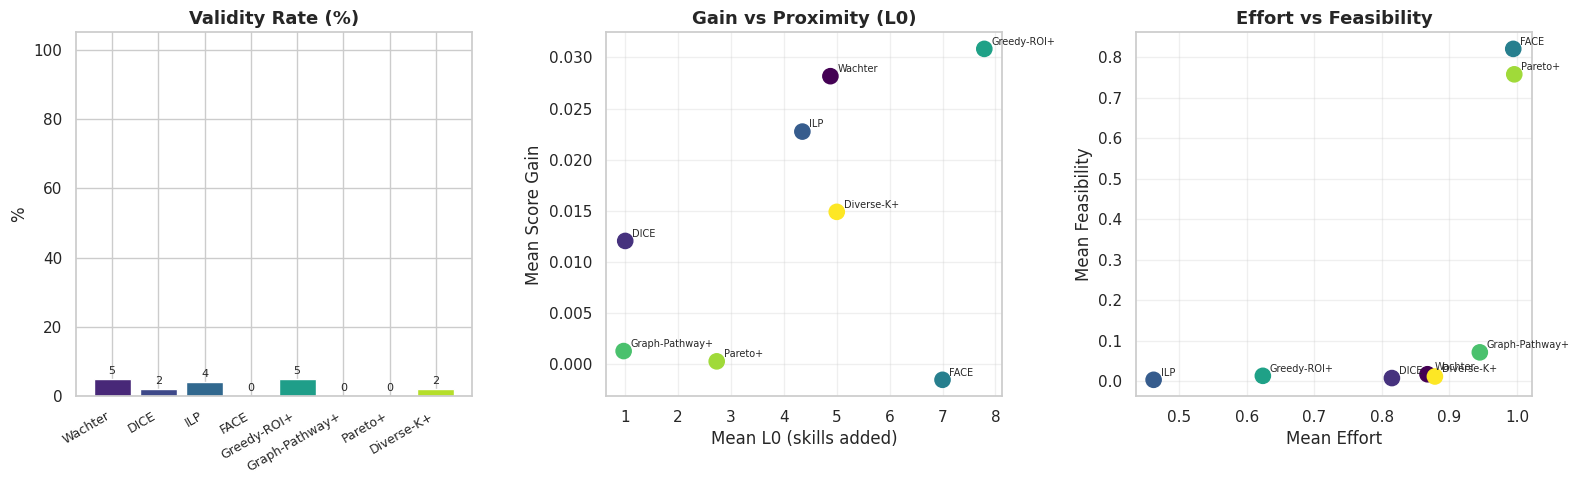

Figure saved.


In [18]:
# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Validity
ax = axes[0]
vals = [100 * np.mean(metrics[m]['valid']) for m in METHOD_NAMES if metrics[m]['valid']]
mnames = [m for m in METHOD_NAMES if metrics[m]['valid']]
bars = ax.bar(mnames, vals, color=sns.color_palette('viridis', len(mnames)))
ax.set_title('Validity Rate (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('%')
ax.set_ylim(0, 105)
ax.set_xticklabels(mnames, rotation=30, ha='right', fontsize=9)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{v:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Gain vs L0 (Pareto front look)
ax = axes[1]
gains = [np.mean(metrics[m]['gain']) for m in mnames]
l0s   = [np.mean(metrics[m]['L0'])   for m in mnames]
sc = ax.scatter(l0s, gains, s=120, c=range(len(mnames)),
                cmap='viridis', zorder=3)
for i, m in enumerate(mnames):
    ax.annotate(m, (l0s[i], gains[i]), textcoords='offset points',
                xytext=(5, 3), fontsize=7)
ax.set_xlabel('Mean L0 (skills added)')
ax.set_ylabel('Mean Score Gain')
ax.set_title('Gain vs Proximity (L0)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Effort vs Feasibility
ax = axes[2]
effs  = [np.mean(metrics[m]['effort'])      for m in mnames]
feas  = [np.mean(metrics[m]['feasibility']) for m in mnames]
ax.scatter(effs, feas, s=120, c=range(len(mnames)), cmap='viridis', zorder=3)
for i, m in enumerate(mnames):
    ax.annotate(m, (effs[i], feas[i]), textcoords='offset points',
                xytext=(5, 3), fontsize=7)
ax.set_xlabel('Mean Effort')
ax.set_ylabel('Mean Feasibility')
ax.set_title('Effort vs Feasibility', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recourse_metrics_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')


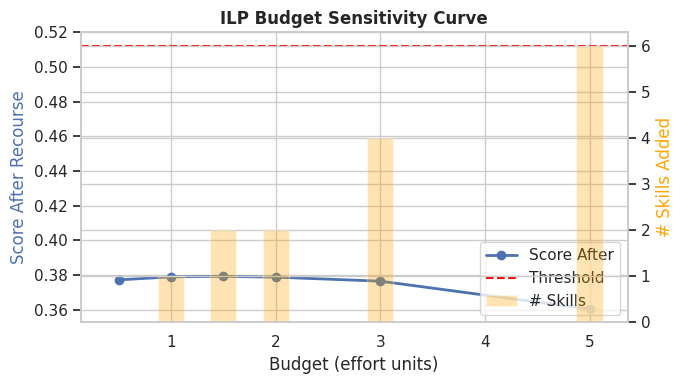

In [19]:
# ── ILP Budget Sweep (single candidate example) ──────────────────────────────
sample = eval_df.iloc[0]
enc_s  = encode_sep(sample[res_col], sample[jd_col])
sweep  = ilp.sweep(enc_s, sample['res_skill_ids'], sample['jd_skill_ids'],
                   sample['extracted_skills_res'], sample['extracted_skills_jd'])

budgets = [pt['budget']     for pt in sweep]
scores  = [pt['score_after'] for pt in sweep]
n_sk    = [pt['proximity_l0'] for pt in sweep]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(budgets, scores, 'b-o', label='Score After', linewidth=2)
ax1.axhline(THRESHOLD_ABS, color='red', linestyle='--', label='Threshold')
ax2.bar(budgets, n_sk, alpha=0.3, color='orange', label='# Skills', width=0.25)
ax1.set_xlabel('Budget (effort units)')
ax1.set_ylabel('Score After Recourse', color='b')
ax2.set_ylabel('# Skills Added', color='orange')
ax1.set_title('ILP Budget Sensitivity Curve', fontsize=12, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.savefig('ilp_budget_sweep_v3.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Qualitative Demo — Single Candidate
# ══════════════════════════════════════════════════════════════════════════════
DEMO_IDX = 0
row = eval_df.iloc[DEMO_IDX]
jd_col_use = 'smart_jd_text' if 'smart_jd_text' in row.index else 'jd_text'

enc_d = encode_sep(row['resume_text'], row[jd_col_use])
_set_cache(enc_d, row['jd_skill_ids'])
base_sc, gates, t_sc, g_sc = score_moe(enc_d, row['res_skill_ids'], row['jd_skill_ids'])

print('=' * 65)
print(f'Candidate #{DEMO_IDX}')
print(f'  Resume skills  : {row["extracted_skills_res"][:10]}')
print(f'  JD skills      : {row["extracted_skills_jd"][:10]}')
print(f'  Base score     : {base_sc:.4f}  ({score_to_label(base_sc)})')
print(f'  Text score     : {t_sc:.4f}')
print(f'  Graph score    : {g_sc:.4f}')
print(f'  Gates          : text={float(gates[0]):.3f}  graph={float(gates[1]):.3f}')
print(f'  Threshold      : {THRESHOLD_ABS:.4f}')
print('=' * 65)

res = run_all_methods(enc_d, row['res_skill_ids'], row['jd_skill_ids'],
                      row['extracted_skills_res'], row['extracted_skills_jd'])

df_demo = results_to_df(res)
print()
display(df_demo)


Candidate #0
  Resume skills  : ['jenkins', 'infrastructure', 'security', 'sql', 'python', 'mongodb', 'puppet', 'quality', 'plans', 'information systems']
  JD skills      : ['passion', 'infrastructure', 'geometry', 'c++', 'math', 'architecture', 'docker', 'electrical engineering', 'logistics', 'experience']
  Base score     : 0.3772  (Potential Fit)
  Text score     : 0.5096
  Graph score    : 0.1753
  Gates          : text=0.604  graph=0.396
  Threshold      : 0.5125
[invalid] Wachter               score 0.377 -> 0.380  gain=+0.003  L0=5  effort=0.92  feas=0.04
[invalid] DICE                  score 0.377 -> 0.379  gain=+0.002  L0=1  effort=0.77  feas=0.00
[invalid] ILP                   score 0.377 -> 0.379  gain=+0.002  L0=2  effort=0.85  feas=0.00
[invalid] FACE                  score 0.377 -> 0.380  gain=+0.003  L0=7  effort=0.99  feas=0.42
[invalid] Greedy-ROI+           score 0.377 -> 0.380  gain=+0.003  L0=8  effort=0.92  feas=0.03
[invalid] Graph-Pathway+        score 0.377 ->

,Score Before,Score After,Gain,Valid,L0,Effort,Feasibility,Sem. Prox.,Skills Added
Method,,,,,,,,,
Wachter,0.3772,0.3799,0.0027,False,5,0.920,0.038,0.662,"culinary degree, car maintenance, software mai..."
DICE,0.3772,0.3790,0.0018,False,1,0.775,0.002,0.205,culinary degree
ILP,0.3772,0.3788,0.0016,False,2,0.846,0.002,-0.123,"anesthesiologist, culinary degree"
FACE,0.3772,0.3803,0.0031,False,7,0.995,0.417,0.683,"communication skills, high school diploma, pro..."
Greedy-ROI+,0.3772,0.3805,0.0033,False,8,0.917,0.035,0.764,"culinary degree, timing belt, 401k matching pl..."
Graph-Pathway+,0.3772,0.3777,0.0005,False,1,0.967,0.004,0.618,estimation
Pareto+,0.3772,0.3795,0.0022,False,4,0.996,0.575,0.679,"problemsolving skills, interpersonal skills, o..."
Diverse-K+,0.3772,0.3731,-0.0041,False,5,0.898,0.002,0.247,"culinary degree, anesthesiologist, user storie..."


In [21]:
# ── Robustness check on demo candidate ─────────────────────────────────────
print('\nRobustness (fraction of noisy-gate trials still valid):')
for name, r in res.items():
    if r is not None and r.skills_added:
        rob = evaluate_robustness(enc_d, row['res_skill_ids'], row['jd_skill_ids'],
                                  r.skills_added, n_trials=30)
        print(f'  {name:22s}: {rob:.2f}')
    elif r is not None:
        print(f'  {name:22s}: n/a (no skills added)')



Robustness (fraction of noisy-gate trials still valid):
  Wachter               : 0.00
  DICE                  : 0.00
  ILP                   : 0.00
  FACE                  : 0.00
  Greedy-ROI+           : 0.00
  Graph-Pathway+        : 0.00
  Pareto+               : 0.00
  Diverse-K+            : 0.00


In [22]:
# ── DICE Diversity Radar ─────────────────────────────────────────────────────
dice_list = dice.run(enc_d, row['res_skill_ids'], row['jd_skill_ids'],
                     row['extracted_skills_res'], row['extracted_skills_jd'])

print(f'DICE produced {len(dice_list)} diverse counterfactuals:')
for i, cf in enumerate(dice_list):
    print(f'  CF {i+1}: {cf.skills_added}  |  score={cf.score_after:.4f}  '
          f'feasibility={cf.feasibility:.3f}')


DICE produced 1 diverse counterfactuals:
  CF 1: ['culinary degree']  |  score=0.3790  feasibility=0.002


Total solutions: 61  |  Pareto front size: 7  |  HV: 0.004271
Best selection : ['problemsolving skills', 'interpersonal skills', 'organizational skills', 'customer service']  score=0.3795  effort=0.996


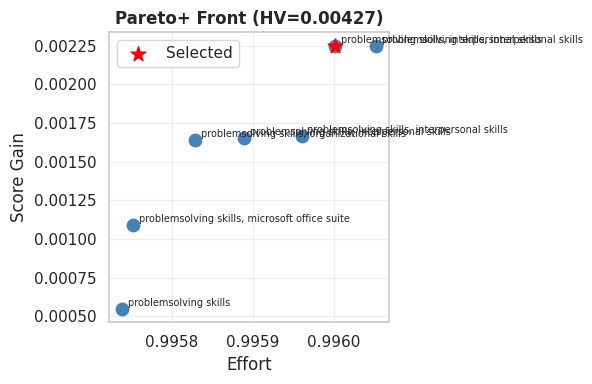

In [23]:
# ── Pareto+ Front Visualisation ──────────────────────────────────────────────
r_pareto = pareto_plus.run(enc_d, row['res_skill_ids'], row['jd_skill_ids'],
                            row['extracted_skills_res'], row['extracted_skills_jd'])

front = r_pareto.extra.get('pareto_front', [])
all_s = r_pareto.extra.get('n_solutions', 0)
hv    = r_pareto.extra.get('hypervolume', 0.0)

print(f'Total solutions: {all_s}  |  Pareto front size: {len(front)}  |  HV: {hv:.6f}')
print(f'Best selection : {r_pareto.skills_added}  '
      f'score={r_pareto.score_after:.4f}  effort={r_pareto.effort:.3f}')

if front:
    fig, ax = plt.subplots(figsize=(6, 4))
    efforts = [p['effort'] for p in front]
    gains   = [p['gain']   for p in front]
    ax.scatter(efforts, gains, c='steelblue', s=80, zorder=3)
    for p in front:
        ax.annotate(', '.join(p['skills'][:2]),
                    (p['effort'], p['gain']),
                    textcoords='offset points', xytext=(4, 2), fontsize=7)
    # Mark selected
    ax.scatter([r_pareto.effort], [r_pareto.gain], c='red', s=120,
               marker='*', zorder=5, label='Selected')
    ax.set_xlabel('Effort')
    ax.set_ylabel('Score Gain')
    ax.set_title(f'Pareto+ Front (HV={hv:.5f})', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pareto_front_v3.png', dpi=150, bbox_inches='tight')
    plt.show()


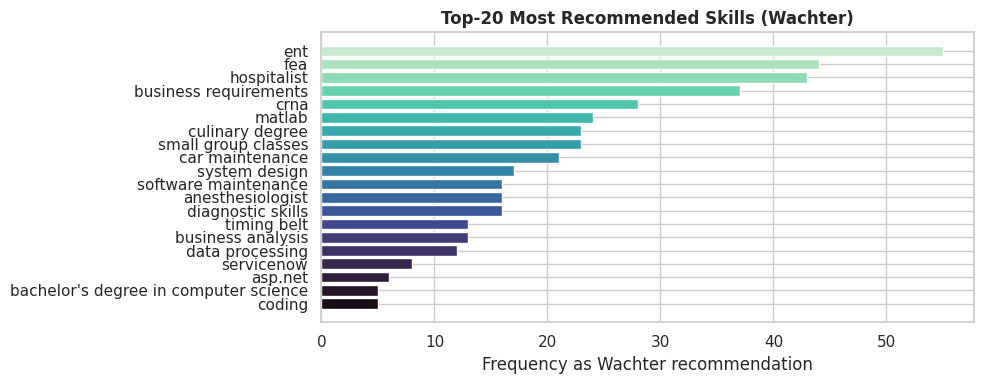

Unique skills recommended by Wachter: 59


In [24]:
# ── Coverage and Skill Diversity across evaluated candidates ─────────────────
from collections import Counter

# Reuse skills already collected during the evaluation loop (no re-inference)
skill_counts = Counter(wachter_skills_log)

top20_skills = skill_counts.most_common(20)
if top20_skills:
    skills_top, freqs_top = zip(*top20_skills)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(list(reversed(skills_top)), list(reversed(freqs_top)),
            color=sns.color_palette('mako', len(skills_top)))
    ax.set_xlabel('Frequency as Wachter recommendation')
    ax.set_title('Top-20 Most Recommended Skills (Wachter)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('top_skills_wachter_v3.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'Unique skills recommended by Wachter: {len(skill_counts)}')


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Publication-Quality Results Table
# ══════════════════════════════════════════════════════════════════════════════
pub_rows = []
for m in METHOD_NAMES:
    d = metrics[m]
    if not d['valid']: continue
    pub_rows.append({
        'Method':          m,
        'Validity (%)':    f"{100 * np.mean(d['valid']):.1f}",
        'Mean Gain':       f"{np.mean(d['gain']):.4f}",
        'Mean L0':         f"{np.mean(d['L0']):.2f}",
        'Mean Effort':     f"{np.mean(d['effort']):.3f}",
        'Feasibility':     f"{np.mean(d['feasibility']):.3f}",
        'Sem. Proximity':  f"{np.mean(d['sem_prox']):.3f}",
    })

pub_df = pd.DataFrame(pub_rows).set_index('Method')
print('\n=== Table: Recourse Method Comparison (MoEv2, n={}) ==='.format(len(eval_df)))
print(pub_df.to_string())
print()
pub_df.style.highlight_max(axis=0, color='#c8e6c9').highlight_min(axis=0, color='#ffcdd2')



=== Table: Recourse Method Comparison (MoEv2, n=100) ===
               Validity (%) Mean Gain Mean L0 Mean Effort Feasibility Sem. Proximity
Method                                                                              
Wachter                 5.0    0.0282    4.88       0.867       0.017          0.159
DICE                    2.0    0.0120    1.00       0.815       0.007         -0.178
ILP                     4.0    0.0227    4.35       0.462       0.003         -0.203
FACE                    0.0   -0.0015    7.00       0.994       0.820          0.852
Greedy-ROI+             5.0    0.0308    7.79       0.624       0.013          0.213
Graph-Pathway+          0.0    0.0013    0.97       0.945       0.071          0.606
Pareto+                 0.0    0.0003    2.73       0.996       0.757          0.871
Diverse-K+              2.0    0.0149    5.00       0.878       0.011          0.183



,Validity (%),Mean Gain,Mean L0,Mean Effort,Feasibility,Sem. Proximity
Method,,,,,,
Wachter,5.0,0.0282,4.88,0.867,0.017,0.159
DICE,2.0,0.0120,1.00,0.815,0.007,-0.178
ILP,4.0,0.0227,4.35,0.462,0.003,-0.203
FACE,0.0,-0.0015,7.00,0.994,0.820,0.852
Greedy-ROI+,5.0,0.0308,7.79,0.624,0.013,0.213
Graph-Pathway+,0.0,0.0013,0.97,0.945,0.071,0.606
Pareto+,0.0,0.0003,2.73,0.996,0.757,0.871
Diverse-K+,2.0,0.0149,5.00,0.878,0.011,0.183


In [26]:
# ── Save results ─────────────────────────────────────────────────────────────
save_path = '/kaggle/working' if ON_KAGGLE else '.'
pub_df.to_csv(os.path.join(save_path, 'recourse_results_v3.csv'))
print(f'Results saved to {save_path}/recourse_results_v3.csv')
summary_df.to_csv(os.path.join(save_path, 'recourse_summary_v3.csv'))
print(f'Summary saved to {save_path}/recourse_summary_v3.csv')
print('\nDone.')


Results saved to /kaggle/working/recourse_results_v3.csv
Summary saved to /kaggle/working/recourse_summary_v3.csv

Done.


---
## Extended Visualisations

Publication-quality figures for all 8 recourse methods.


In [27]:
# ── Visualisation setup ───────────────────────────────────────────────────────
import os, networkx as nx, matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

VIS_DIR = '/kaggle/working/figures' if ON_KAGGLE else 'figures'
os.makedirs(VIS_DIR, exist_ok=True)

METHOD_COLORS = {
    'Wachter':        '#4a90d9',
    'DICE':           '#e91e8c',
    'ILP':            '#2ecc71',
    'FACE':           '#e67e22',
    'Greedy-ROI+':    '#9b59b6',
    'Graph-Pathway+': '#1abc9c',
    'Pareto+':        '#e74c3c',
    'Diverse-K+':     '#f39c12',
}

def savefig(name):
    plt.savefig(os.path.join(VIS_DIR, name), dpi=150, bbox_inches='tight')
    print(f'Saved {name}')

print(f'Figures -> {VIS_DIR}')


Figures -> /kaggle/working/figures


Saved fig1_comparison_dashboard.png


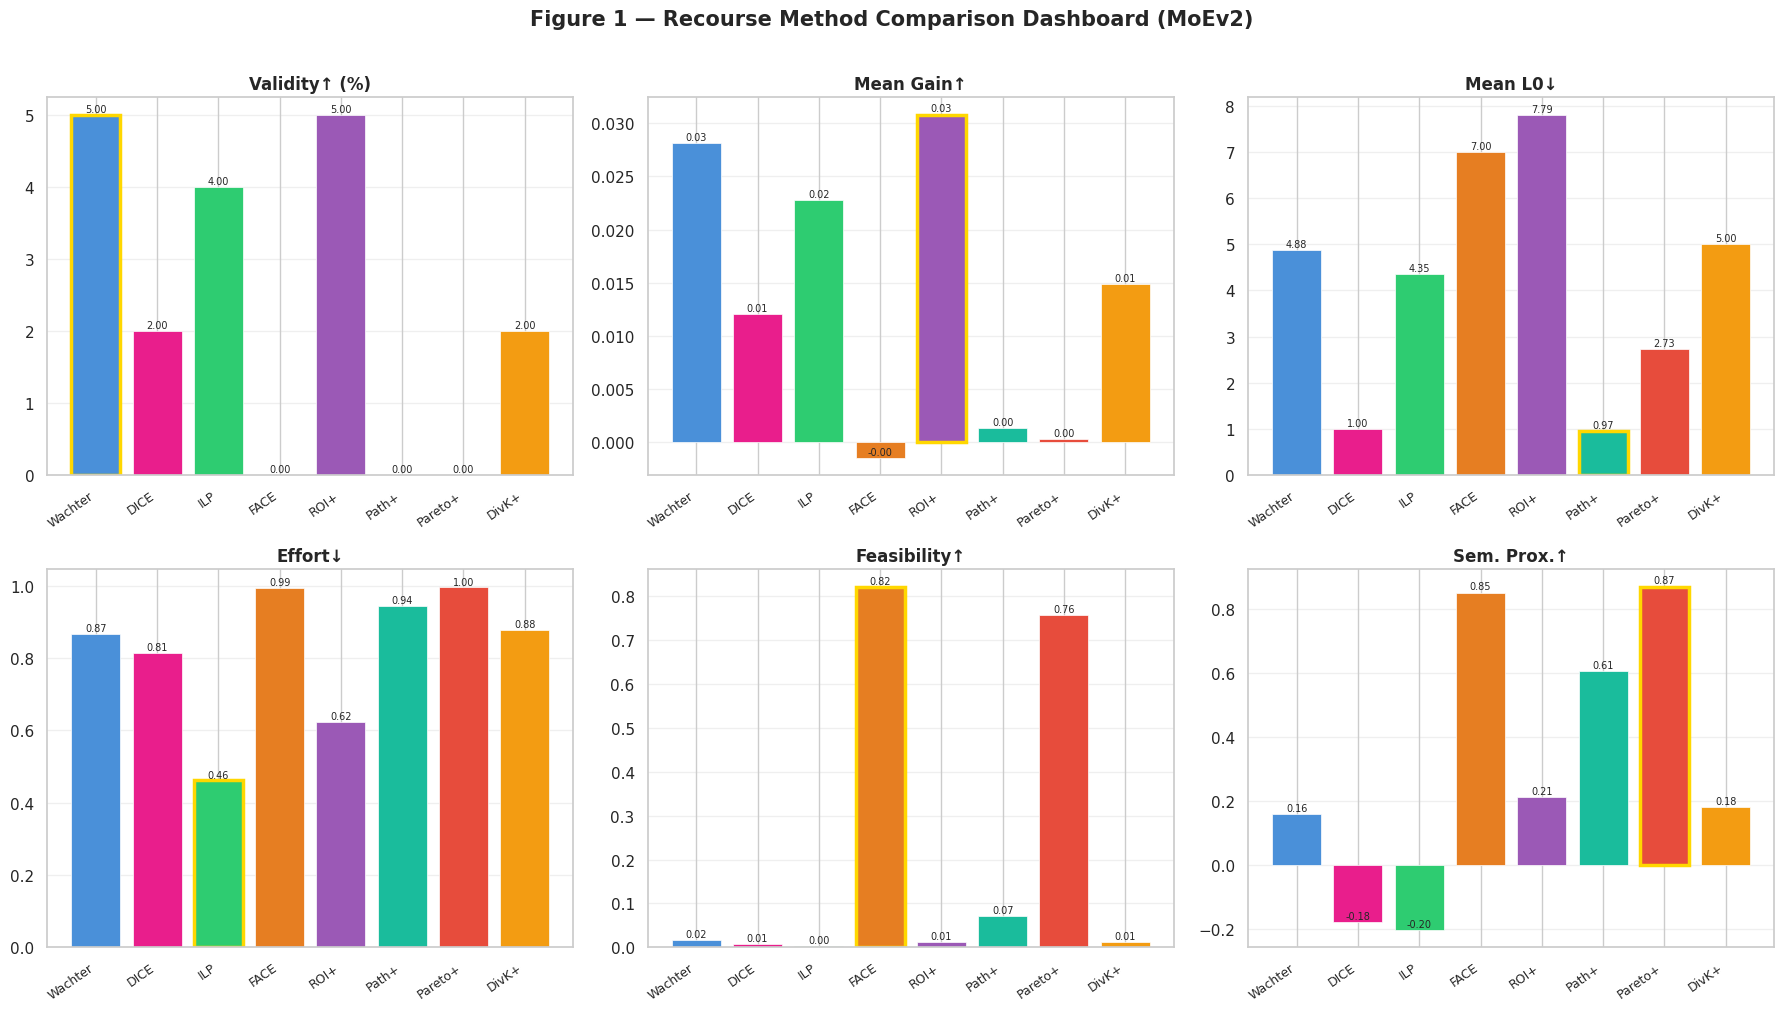

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Comprehensive Method Comparison Dashboard (8 metrics)
# ══════════════════════════════════════════════════════════════════════════════
metric_keys  = ['valid', 'gain', 'L0', 'effort', 'feasibility', 'sem_prox']
metric_labels = ['Validity↑ (%)', 'Mean Gain↑', 'Mean L0↓',
                 'Effort↓', 'Feasibility↑', 'Sem. Prox.↑']
flip_low     = {'L0', 'effort'}   # lower is better

mnames = [m for m in METHOD_NAMES if metrics[m]['valid']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 1 — Recourse Method Comparison Dashboard (MoEv2)',
             fontsize=15, fontweight='bold', y=1.01)

for ax, key, lbl in zip(axes.flat, metric_keys, metric_labels):
    if key == 'valid':
        vals = [100 * np.mean(metrics[m][key]) for m in mnames]
    else:
        vals = [np.mean(metrics[m][key]) for m in mnames]
    colors = [METHOD_COLORS.get(m, '#888') for m in mnames]
    bars   = ax.bar(range(len(mnames)), vals, color=colors,
                    edgecolor='white', linewidth=0.5)

    best_idx = int(np.argmin(vals) if key in flip_low else np.argmax(vals))
    bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(2.5)

    ax.set_title(lbl, fontweight='bold', pad=6)
    ax.set_xticks(range(len(mnames)))
    ax.set_xticklabels(
        [m.replace('Graph-Pathway+', 'Path+').replace('Greedy-ROI+', 'ROI+')
          .replace('Diverse-K+', 'DivK+') for m in mnames],
        rotation=35, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003 * (max(vals) - min(vals) + 1e-6),
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig('fig1_comparison_dashboard.png')
plt.show()


Saved fig2_radar_chart.png


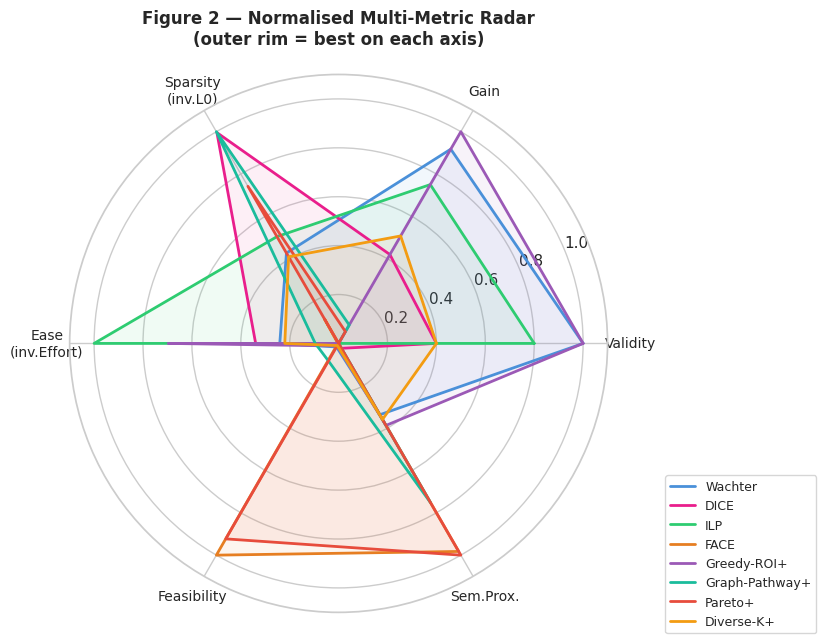

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Radar Chart: Normalised Multi-Metric Profile per Method
# ══════════════════════════════════════════════════════════════════════════════
radar_keys   = ['valid', 'gain', 'L0', 'effort', 'feasibility', 'sem_prox']
radar_labels = ['Validity', 'Gain', 'Sparsity\n(inv.L0)',
                'Ease\n(inv.Effort)', 'Feasibility', 'Sem.Prox.']

# Build normalised matrix
raw = {}
for m in mnames:
    raw[m] = {
        'valid':       np.mean(metrics[m]['valid']),
        'gain':        np.mean(metrics[m]['gain']),
        'L0':          np.mean(metrics[m]['L0']),
        'effort':      np.mean(metrics[m]['effort']),
        'feasibility': np.mean(metrics[m]['feasibility']),
        'sem_prox':    np.mean(metrics[m]['sem_prox']),
    }

# Invert lower-is-better metrics
col_max = {k: max(raw[m][k] for m in mnames) + 1e-9 for k in radar_keys}
col_min = {k: min(raw[m][k] for m in mnames)         for k in radar_keys}

def normalise(m, k):
    v = raw[m][k]
    if k in ('L0', 'effort'):                           # invert
        return 1.0 - (v - col_min[k]) / (col_max[k] - col_min[k] + 1e-9)
    return (v - col_min[k]) / (col_max[k] - col_min[k] + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(radar_keys), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for mname in mnames:
    vals = [normalise(mname, k) for k in radar_keys] + [normalise(mname, radar_keys[0])]
    color = METHOD_COLORS.get(mname, '#888')
    ax.plot(angles, vals, color=color, lw=2, label=mname)
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10)
ax.set_ylim(0, 1.1)
ax.set_title('Figure 2 — Normalised Multi-Metric Radar\n'
             '(outer rim = best on each axis)', fontweight='bold', pad=22)
ax.legend(loc='lower right', bbox_to_anchor=(1.4, -0.05), fontsize=9)
plt.tight_layout()
savefig('fig2_radar_chart.png')
plt.show()


Saved fig3_pareto_efficiency.png


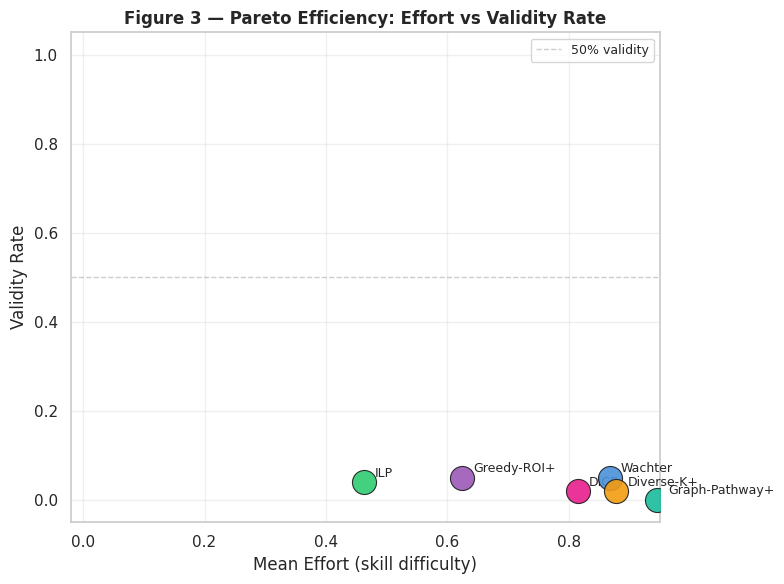

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Pareto Efficiency Scatter: Effort vs Validity
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

for mname in mnames:
    effort_m = np.mean(metrics[mname]['effort'])
    valid_m  = np.mean(metrics[mname]['valid'])
    l0_m     = np.mean(metrics[mname]['L0'])
    ax.scatter(effort_m, valid_m,
               s=300, color=METHOD_COLORS.get(mname, '#888'),
               zorder=5, edgecolors='k', linewidths=0.8, alpha=0.9)
    ax.annotate(mname, (effort_m, valid_m),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Mean Effort (skill difficulty)', fontsize=12)
ax.set_ylabel('Validity Rate', fontsize=12)
ax.set_title('Figure 3 — Pareto Efficiency: Effort vs Validity Rate',
             fontweight='bold', fontsize=12)
ax.axhline(0.5, ls='--', color='grey', alpha=0.4, lw=1, label='50% validity')
ax.set_xlim(-0.02, 0.95)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('fig3_pareto_efficiency.png')
plt.show()


Saved fig4_score_progression.png


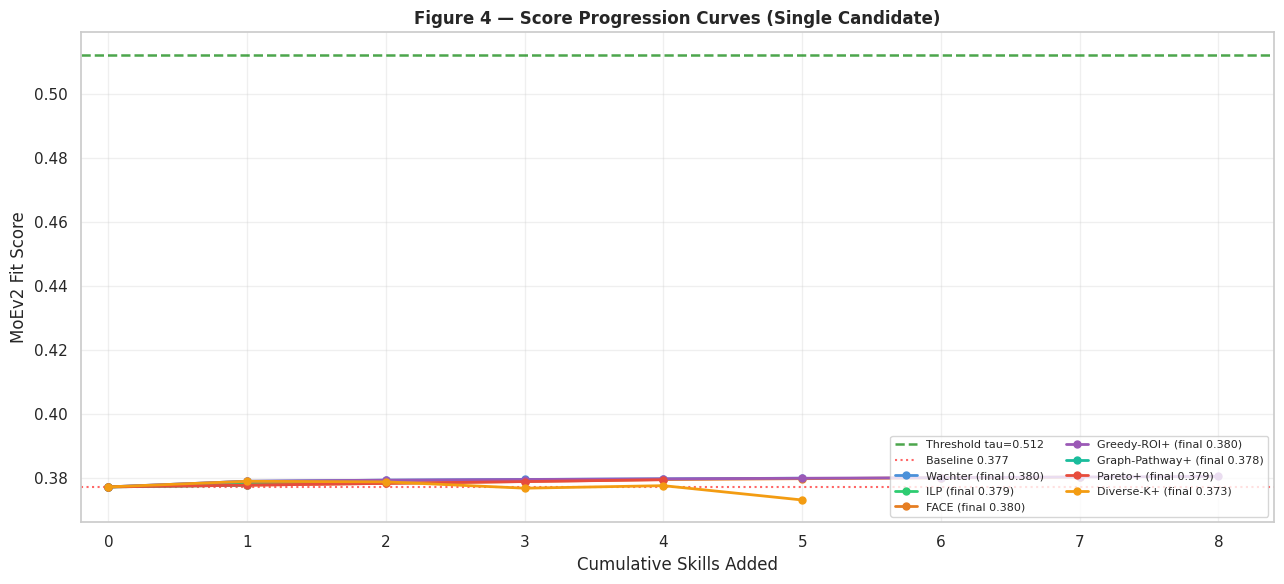

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Score Progression Curves (step-by-step, single candidate)
# ══════════════════════════════════════════════════════════════════════════════
jd_col_use = 'smart_jd_text' if 'smart_jd_text' in eval_df.columns else 'jd_text'
pilot      = eval_df.iloc[0]
enc_pilot  = encode_sep(pilot['resume_text'], pilot[jd_col_use])
r_ids_p    = pilot['res_skill_ids']
j_ids_p    = pilot['jd_skill_ids']
res_sk_p   = pilot['extracted_skills_res']
jd_sk_p    = pilot['extracted_skills_jd']
base_p, *_ = score_moe(enc_pilot, r_ids_p, j_ids_p)

all_methods_map = {
    'Wachter':        wachter,
    'ILP':            ilp,
    'FACE':           face,
    'Greedy-ROI+':    greedy_roi,
    'Graph-Pathway+': graph_path,
    'Pareto+':        pareto_plus,
    'Diverse-K+':     diverse_k,
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.axhline(THRESHOLD_ABS, ls='--', color='green', alpha=0.7, lw=1.8,
           label=f'Threshold tau={THRESHOLD_ABS:.3f}')
ax.axhline(base_p, ls=':', color='red', alpha=0.6, lw=1.5,
           label=f'Baseline {base_p:.3f}')

for mname, mobj in all_methods_map.items():
    try:
        _set_cache(enc_pilot, j_ids_p)
        r = mobj.run(enc_pilot, r_ids_p, j_ids_p, res_sk_p, jd_sk_p)
        if not r.skills_added:
            continue
        # Build step-by-step trajectory
        cur_ids = list(set(r_ids_p)); traj = [base_p]
        for s in r.skills_added:
            if s in skill_to_id:
                cur_ids = list(set(cur_ids) | {skill_to_id[s]})
                sc = score_with_extra_ids(enc_pilot, list(set(r_ids_p)), j_ids_p,
                                          [skill_to_id[sk] for sk in r.skills_added
                                           if sk in skill_to_id and sk in r.skills_added[:r.skills_added.index(s)+1]])
                traj.append(sc)
        color = METHOD_COLORS.get(mname, '#888')
        ax.plot(range(len(traj)), traj, marker='o', markersize=5,
                color=color, lw=2, label=f'{mname} (final {traj[-1]:.3f})')
    except Exception as exc:
        print(f'{mname} skipped: {exc}')

ax.set_xlabel('Cumulative Skills Added', fontsize=12)
ax.set_ylabel('MoEv2 Fit Score', fontsize=12)
ax.set_title('Figure 4 — Score Progression Curves (Single Candidate)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.set_xlim(-0.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('fig4_score_progression.png')
plt.show()


ILP sweep:   0%|          | 0/20 [00:00<?, ?it/s]

Saved fig5_budget_sensitivity.png


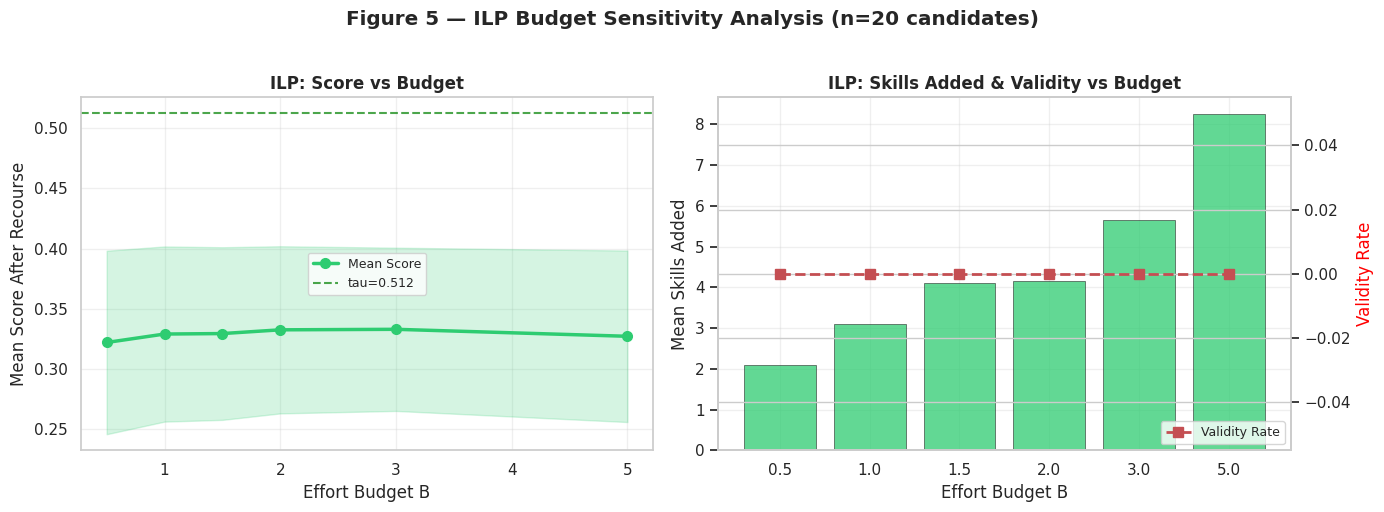

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — ILP Budget Sensitivity (20 candidates, mean +/- std band)
# ══════════════════════════════════════════════════════════════════════════════
budget_records = []
sample_20 = eval_df.sample(min(20, len(eval_df)), random_state=42)
for _, row in tqdm(sample_20.iterrows(), total=len(sample_20), desc='ILP sweep'):
    enc_b = encode_sep(row[res_col], row[jd_col_use])
    _set_cache(enc_b, row['jd_skill_ids'])
    for B in ILPRecourse.BUDGETS:
        r = ilp.run(enc_b, row['res_skill_ids'], row['jd_skill_ids'],
                    row['extracted_skills_res'], row['extracted_skills_jd'], budget=B)
        budget_records.append({'budget': B, 'score': r.score_after,
                                'n_skills': r.proximity_l0, 'valid': int(r.valid)})

df_bud = (pd.DataFrame(budget_records)
          .groupby('budget')
          .agg(mean_score=('score','mean'), std_score=('score','std'),
               mean_n=('n_skills','mean'), validity=('valid','mean'))
          .reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

std_fill = df_bud['std_score'].fillna(0)
ax1.fill_between(df_bud.budget,
                 df_bud.mean_score - std_fill,
                 df_bud.mean_score + std_fill,
                 alpha=0.2, color=METHOD_COLORS['ILP'])
ax1.plot(df_bud.budget, df_bud.mean_score, 'o-',
         color=METHOD_COLORS['ILP'], lw=2.5, ms=7, label='Mean Score')
ax1.axhline(THRESHOLD_ABS, ls='--', color='green', alpha=0.7,
            label=f'tau={THRESHOLD_ABS:.3f}')
ax1.set_xlabel('Effort Budget B', fontsize=12)
ax1.set_ylabel('Mean Score After Recourse', fontsize=12)
ax1.set_title('ILP: Score vs Budget', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

bars = ax2.bar(df_bud.budget.astype(str), df_bud.mean_n,
               color=METHOD_COLORS['ILP'], alpha=0.75, edgecolor='k', linewidth=0.5)
ax2t = ax2.twinx()
ax2t.plot(df_bud.budget.astype(str), df_bud.validity, 'rs--',
          lw=2, ms=7, label='Validity Rate')
ax2.set_xlabel('Effort Budget B', fontsize=12)
ax2.set_ylabel('Mean Skills Added', fontsize=12)
ax2t.set_ylabel('Validity Rate', fontsize=12, color='red')
ax2.set_title('ILP: Skills Added & Validity vs Budget', fontweight='bold')
ax2t.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('Figure 5 — ILP Budget Sensitivity Analysis (n=20 candidates)',
             fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig5_budget_sensitivity.png')
plt.show()


Gate sweep:   0%|          | 0/30 [00:00<?, ?it/s]

Saved fig6_gate_distributions.png


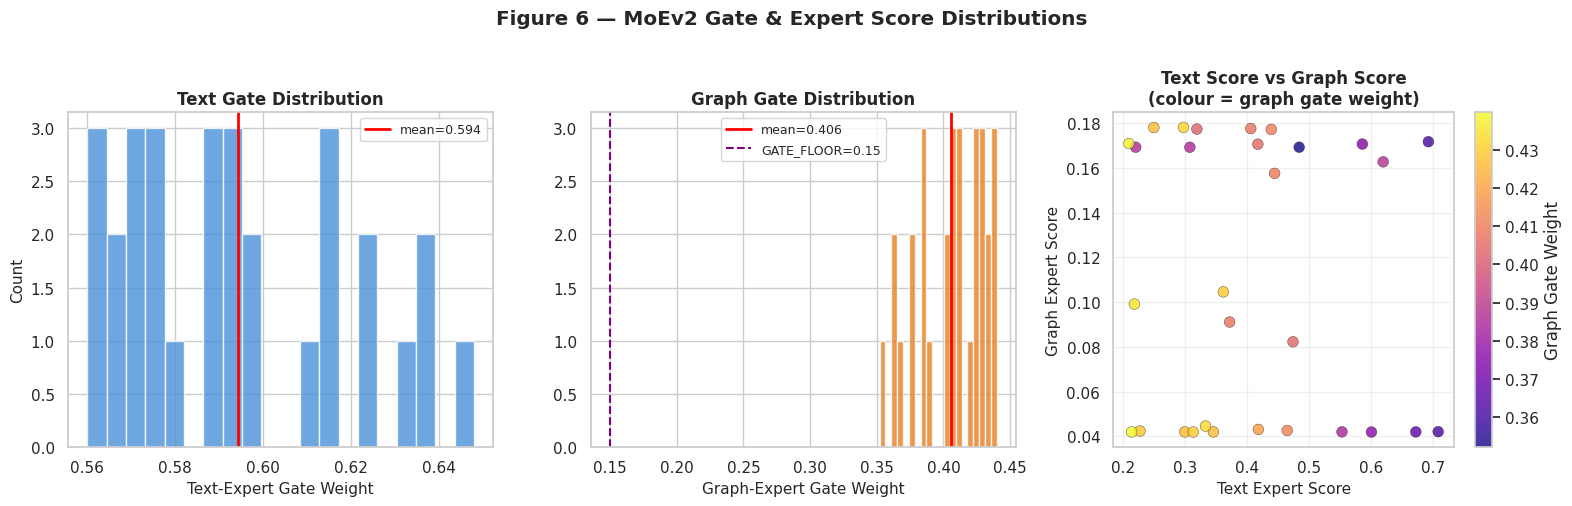

Mean text gate:  0.594
Mean graph gate: 0.406


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Gate Weight Distribution: Text vs Graph Expert per Method
# Gate weights reveal which expert each method relies on more heavily.
# ══════════════════════════════════════════════════════════════════════════════
gate_records = []
sample_30 = eval_df.sample(min(30, len(eval_df)), random_state=7)

for _, row in tqdm(sample_30.iterrows(), total=len(sample_30), desc='Gate sweep'):
    enc_g   = encode_sep(row[res_col], row[jd_col_use])
    _set_cache(enc_g, row['jd_skill_ids'])
    _, gates, t_sc, g_sc = score_moe(enc_g, row['res_skill_ids'], row['jd_skill_ids'])
    gate_records.append({
        'gate_text':  float(gates[0].item()),
        'gate_graph': float(gates[1].item()),
        'text_score': t_sc,
        'graph_score': g_sc,
    })

df_gates = pd.DataFrame(gate_records)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 6 — MoEv2 Gate & Expert Score Distributions',
             fontweight='bold', y=1.01)

# Text gate distribution
axes[0].hist(df_gates['gate_text'], bins=20, color='#4a90d9', alpha=0.8, edgecolor='white')
axes[0].axvline(df_gates['gate_text'].mean(), color='red', lw=2,
                label=f"mean={df_gates['gate_text'].mean():.3f}")
axes[0].set_xlabel('Text-Expert Gate Weight', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Text Gate Distribution', fontweight='bold')
axes[0].legend(fontsize=9)

# Graph gate distribution
axes[1].hist(df_gates['gate_graph'], bins=20, color='#e67e22', alpha=0.8, edgecolor='white')
axes[1].axvline(df_gates['gate_graph'].mean(), color='red', lw=2,
                label=f"mean={df_gates['gate_graph'].mean():.3f}")
axes[1].axvline(GATE_FLOOR, color='purple', lw=1.5, ls='--',
                label=f'GATE_FLOOR={GATE_FLOOR}')
axes[1].set_xlabel('Graph-Expert Gate Weight', fontsize=11)
axes[1].set_title('Graph Gate Distribution', fontweight='bold')
axes[1].legend(fontsize=9)

# Text score vs Graph score scatter
sc = axes[2].scatter(df_gates['text_score'], df_gates['graph_score'],
                     c=df_gates['gate_graph'], cmap='plasma',
                     s=60, alpha=0.8, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=axes[2], label='Graph Gate Weight')
axes[2].set_xlabel('Text Expert Score', fontsize=11)
axes[2].set_ylabel('Graph Expert Score', fontsize=11)
axes[2].set_title('Text Score vs Graph Score\n(colour = graph gate weight)',
                  fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
savefig('fig6_gate_distributions.png')
plt.show()
print(f"Mean text gate:  {df_gates['gate_text'].mean():.3f}")
print(f"Mean graph gate: {df_gates['gate_graph'].mean():.3f}")


Saved fig7_metric_correlation.png


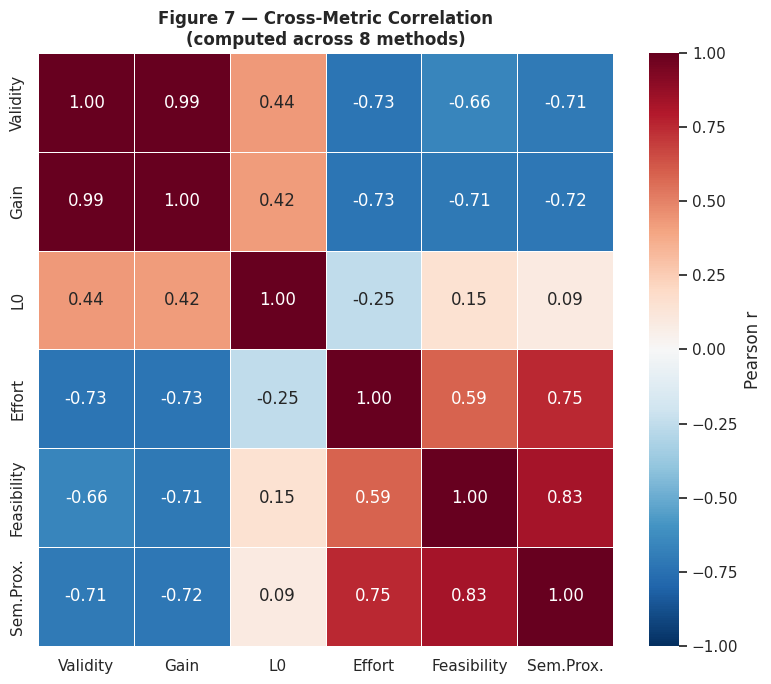

In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Metric Correlation Heatmap across Methods
# ══════════════════════════════════════════════════════════════════════════════
corr_data = {}
for m in mnames:
    corr_data[m] = {
        'Validity':    np.mean(metrics[m]['valid']),
        'Gain':        np.mean(metrics[m]['gain']),
        'L0':          np.mean(metrics[m]['L0']),
        'Effort':      np.mean(metrics[m]['effort']),
        'Feasibility': np.mean(metrics[m]['feasibility']),
        'Sem.Prox.':   np.mean(metrics[m]['sem_prox']),
    }

df_corr = pd.DataFrame(corr_data).T    # methods as rows, metrics as cols
corr_mat = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask_tri = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Figure 7 — Cross-Metric Correlation\n(computed across 8 methods)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
savefig('fig7_metric_correlation.png')
plt.show()


Saved fig8_learning_path_networks.png


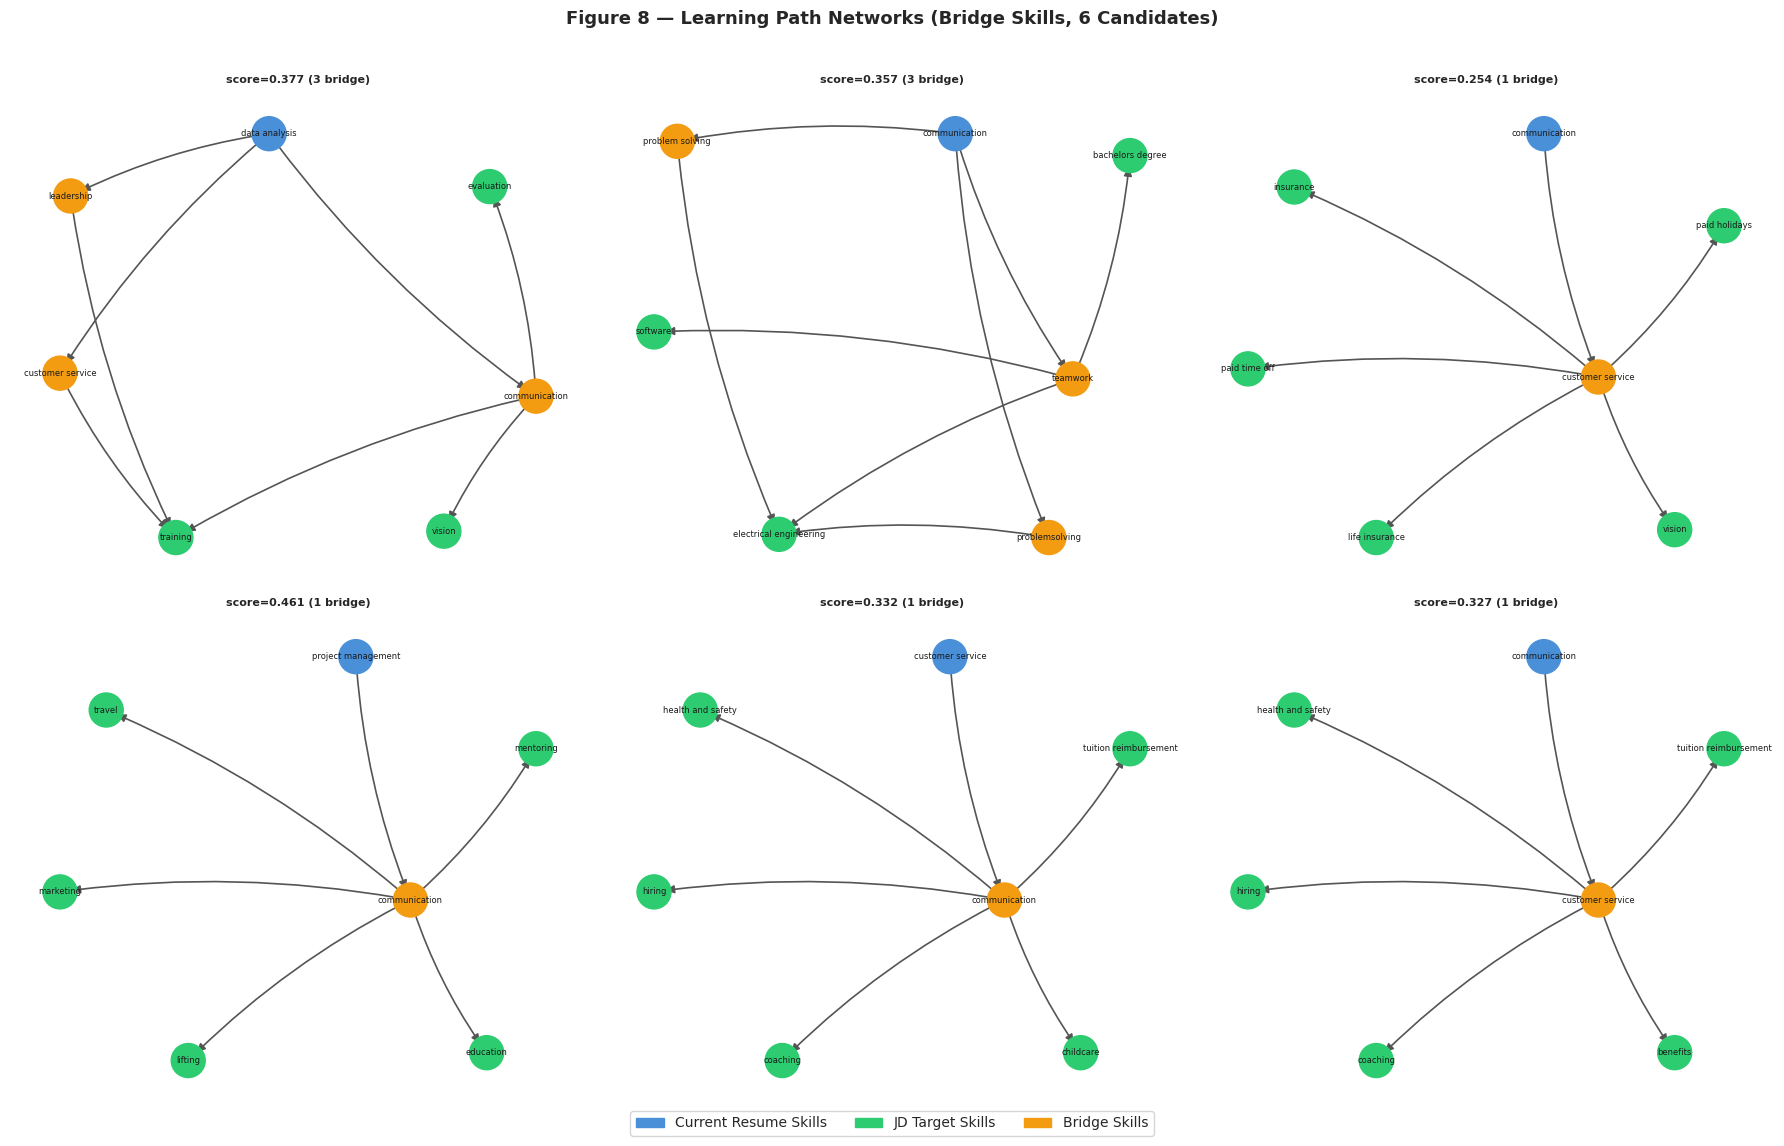

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 8 — Learning Path Network (Graph-Pathway+ on 6 candidates)
# Shows bridge skills that connect resume skills to JD targets.
# ══════════════════════════════════════════════════════════════════════════════

def build_path_triples(res_skills, jd_skills, max_triples=6):
    """2-hop triples: current -> bridge -> JD_target, ranked by edge weight."""
    res_set = set(res_skills); jd_set = set(jd_skills)
    scored  = []
    for cur in res_set:
        for bridge, w1 in adjacency.get(cur, {}).items():
            if bridge in res_set: continue
            for tgt, w2 in adjacency.get(bridge, {}).items():
                if tgt in jd_set and tgt not in res_set:
                    scored.append((w1 + w2, cur, bridge, tgt))
    scored.sort(reverse=True)
    seen_br, seen_tgt, selected = set(), set(), []
    for _, cur, br, tgt in scored:
        if br not in seen_br or tgt not in seen_tgt:
            selected.append((cur, br, tgt))
            seen_br.add(br); seen_tgt.add(tgt)
        if len(selected) >= max_triples: break
    return selected, res_set, jd_set

def draw_path_network(ax, selected, res_set, jd_set, title):
    G = nx.DiGraph()
    for cur, br, tgt in selected:
        G.add_edge(cur, br); G.add_edge(br, tgt)
    if not G.edges():   # 1-hop fallback
        for cur in res_set:
            for tgt in adjacency.get(cur, {}):
                if tgt in jd_set and tgt not in res_set:
                    G.add_edge(cur, tgt)
                    if len(G.edges()) >= 6: break
    if not G.nodes():
        ax.set_title(f'{title}\n(no graph paths)', fontsize=8); ax.axis('off'); return 0
    colors = ['#4a90d9' if n in res_set else '#2ecc71' if n in jd_set else '#f39c12'
              for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42, k=2.5)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=600, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
    if G.edges():
        nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=12,
                               edge_color='#555', width=1.2, ax=ax,
                               connectionstyle='arc3,rad=0.08')
    n_br = sum(1 for n in G.nodes() if n not in res_set and n not in jd_set)
    ax.set_title(f'{title} ({n_br} bridge)', fontsize=8, fontweight='bold')
    ax.axis('off')
    return n_br

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 8 — Learning Path Networks (Bridge Skills, 6 Candidates)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (_, row) in zip(axes.flat, eval_df.head(6).iterrows()):
    enc_i = encode_sep(row[res_col], row[jd_col_use])
    sc_i, *_ = score_moe(enc_i, row['res_skill_ids'], row['jd_skill_ids'])
    sel, rs, js = build_path_triples(row['extracted_skills_res'],
                                      row['extracted_skills_jd'], max_triples=5)
    draw_path_network(ax, sel, rs, js, f'score={sc_i:.3f}')

legend_handles = [
    mpatches.Patch(color='#4a90d9', label='Current Resume Skills'),
    mpatches.Patch(color='#2ecc71', label='JD Target Skills'),
    mpatches.Patch(color='#f39c12', label='Bridge Skills'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
savefig('fig8_learning_path_networks.png')
plt.show()


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 9 — Bridge Skill x JD Target Co-occurrence Heatmap
# Which bridge skills most frequently link resume skills to JD requirements?
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

bridge_ctr = Counter(); target_ctr = Counter()

for _, row in eval_df.iterrows():
    sel, *_ = build_path_triples(row['extracted_skills_res'],
                                  row['extracted_skills_jd'], max_triples=8)
    for _, br, tgt in sel:
        bridge_ctr[br] += 1; target_ctr[tgt] += 1

top_bridges = [s for s, _ in bridge_ctr.most_common(12)]
top_targets = [s for s, _ in target_ctr.most_common(10)]

mat = np.zeros((len(top_bridges), len(top_targets)))
for _, row in eval_df.iterrows():
    sel, *_ = build_path_triples(row['extracted_skills_res'],
                                  row['extracted_skills_jd'], max_triples=8)
    for _, br, tgt in sel:
        if br in top_bridges and tgt in top_targets:
            mat[top_bridges.index(br), top_targets.index(tgt)] += 1

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(mat, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(top_targets)))
ax.set_xticklabels(top_targets, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(top_bridges)))
ax.set_yticklabels(top_bridges, fontsize=9)
for i in range(len(top_bridges)):
    for j in range(len(top_targets)):
        if mat[i, j] > 0:
            ax.text(j, i, int(mat[i, j]), ha='center', va='center',
                    fontsize=8, color='black' if mat[i, j] < mat.max() * 0.6 else 'white')
plt.colorbar(im, ax=ax, label='Co-occurrence count')
ax.set_xlabel('JD Target Skills', fontsize=11)
ax.set_ylabel('Bridge Skills', fontsize=11)
ax.set_title(f'Figure 9 — Bridge Skill x JD Target Heatmap ({len(eval_df)} candidates)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('fig9_bridge_heatmap.png')
plt.show()
print(f'Top bridge skills: {top_bridges[:5]}')
print(f'Top JD targets:    {top_targets[:5]}')


KeyboardInterrupt: 

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 10 — FACE Ablation: Score Weight vs Density Weight
# ══════════════════════════════════════════════════════════════════════════════
ablation_rows = []
sample_abl = eval_df.sample(min(25, len(eval_df)), random_state=99)

for sw in [0.0, 0.25, 0.50, 0.75, 1.0]:
    dw = 1.0 - sw
    face_ab = FACERecourse(score_w=sw, density_w=dw)
    vals, feas_list, n_sk = [], [], []
    for _, row in sample_abl.iterrows():
        enc_ab = encode_sep(row[res_col], row[jd_col_use])
        _set_cache(enc_ab, row['jd_skill_ids'])
        r = face_ab.run(enc_ab, row['res_skill_ids'], row['jd_skill_ids'],
                        row['extracted_skills_res'], row['extracted_skills_jd'])
        vals.append(int(r.valid))
        feas_list.append(r.feasibility)
        n_sk.append(r.proximity_l0)
    ablation_rows.append({'score_w': sw, 'density_w': dw,
                           'validity':    np.mean(vals),
                           'feasibility': np.mean(feas_list),
                           'l0':          np.mean(n_sk)})

df_ab = pd.DataFrame(ablation_rows)
print('FACE Ablation Results:')
print(df_ab.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in [
    (axes[0], 'validity',    'Validity Rate'),
    (axes[1], 'feasibility', 'Feasibility Score'),
    (axes[2], 'l0',          'L0 (skills added)'),
]:
    ax.plot(df_ab.score_w, df_ab[col], 'o-',
            color=METHOD_COLORS['FACE'], lw=2.5, ms=8)
    ax.set_xlabel('Score Weight alpha\n(Density Weight = 1 - alpha)', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(f'FACE: {title}', fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Figure 10 — FACE Ablation: Score-Gain vs Feasibility Trade-off',
             fontweight='bold', y=1.03)
plt.tight_layout()
savefig('fig10_face_ablation.png')
plt.show()


KeyboardInterrupt: 

Saved fig11_l0_distribution.png


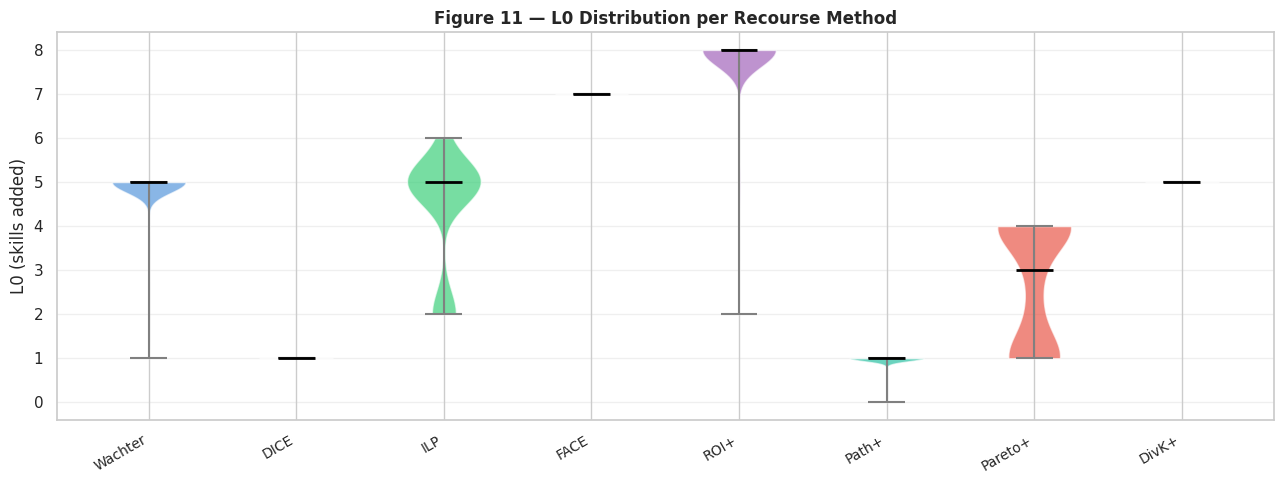

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 11 — L0 Distribution per Method (violin + box)
# How many skills does each method add, and how variable is it?
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))

l0_data  = [metrics[m]['L0']   for m in mnames]
colors   = [METHOD_COLORS.get(m, '#888') for m in mnames]
labels   = [m.replace('Graph-Pathway+','Path+').replace('Greedy-ROI+','ROI+')
             .replace('Diverse-K+','DivK+') for m in mnames]

parts = ax.violinplot(l0_data, positions=range(len(mnames)), showmedians=True,
                      showextrema=True)
for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col); pc.set_alpha(0.65)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
parts['cmins'].set_color('grey');     parts['cmaxes'].set_color('grey')
parts['cbars'].set_color('grey')

ax.set_xticks(range(len(mnames)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('L0 (skills added)', fontsize=12)
ax.set_title('Figure 11 — L0 Distribution per Recourse Method',
             fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
savefig('fig11_l0_distribution.png')
plt.show()


---
## Extended Evaluation: Coverage, Diversity, Robustness

Beyond the six core metrics, we evaluate three additional properties:

| Metric | Definition | Direction |
|--------|-----------|-----------|
| **Coverage** | \|Δ ∩ JD\| / \|JD\| — fraction of JD skills satisfied | ↑ |
| **Diversity** | Mean pairwise Jaccard distance between counterfactuals (DICE) | ↑ |
| **Robustness** | Validity under Gaussian noise on gate weights | ↑ |


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# Extended Evaluation — Coverage, Diversity, Robustness on 30-candidate subset
# ══════════════════════════════════════════════════════════════════════════════
EXT_N    = 30
ext_df   = eval_df.sample(min(EXT_N, len(eval_df)), random_state=7)
jd_col_use = 'smart_jd_text' if 'smart_jd_text' in eval_df.columns else 'jd_text'

ext_metrics = {m: {'coverage': [], 'diversity': [], 'robustness': [], 'valid': []}
               for m in METHOD_NAMES}

for idx, (_, row) in enumerate(tqdm(ext_df.iterrows(), total=len(ext_df),
                                     desc='Extended eval')):
    enc_e   = encode_sep(row[res_col], row[jd_col_use])
    r_ids_e = row['res_skill_ids']
    j_ids_e = row['jd_skill_ids']
    jd_sk_e = set(row['extracted_skills_jd'])
    _set_cache(enc_e, j_ids_e)

    try:
        # DICE — diversity from its multi-CF output
        dice_list = dice.run(enc_e, r_ids_e, j_ids_e,
                             row['extracted_skills_res'], row['extracted_skills_jd'])
        if len(dice_list) > 1:
            divs = []
            for a, b in combinations(dice_list, 2):
                sa, sb = set(a.skills_added), set(b.skills_added)
                divs.append(1 - len(sa & sb) / max(len(sa | sb), 1))
            dice_div = float(np.mean(divs))
        else:
            dice_div = 0.0

        for mname, mobj in [('Wachter',        wachter),
                             ('DICE',           None),     # handled above
                             ('ILP',            ilp),
                             ('FACE',           face),
                             ('Greedy-ROI+',    greedy_roi),
                             ('Graph-Pathway+', graph_path),
                             ('Pareto+',        pareto_plus),
                             ('Diverse-K+',     diverse_k)]:
            if mname == 'DICE':
                r = dice_list[0] if dice_list else None
            else:
                r = mobj.run(enc_e, r_ids_e, j_ids_e,
                             row['extracted_skills_res'], row['extracted_skills_jd'])

            if r is None or not r.skills_added:
                ext_metrics[mname]['coverage'].append(0.)
                ext_metrics[mname]['diversity'].append(0.)
                ext_metrics[mname]['robustness'].append(0.)
                ext_metrics[mname]['valid'].append(0)
                continue

            # Coverage
            cov = len(set(r.skills_added) & jd_sk_e) / max(len(jd_sk_e), 1)
            ext_metrics[mname]['coverage'].append(cov)

            # Diversity (only meaningful for DICE; others get single-path diversity)
            ext_metrics[mname]['diversity'].append(
                dice_div if mname == 'DICE' else
                r.extra.get('diversity', 0.))

            # Robustness
            rob = evaluate_robustness(enc_e, r_ids_e, j_ids_e,
                                      r.skills_added, n_trials=15)
            ext_metrics[mname]['robustness'].append(rob)
            ext_metrics[mname]['valid'].append(int(r.valid))

    except Exception as exc:
        print(f'Row {idx} ({mname}) failed: {exc}')

print('Extended evaluation complete.')


Extended eval:   0%|          | 0/30 [00:00<?, ?it/s]

Extended evaluation complete.


In [40]:
# ── Extended metrics summary table ───────────────────────────────────────────
ext_rows = []
for m in METHOD_NAMES:
    d = ext_metrics[m]
    if not d['valid']: continue
    ext_rows.append({
        'Method':      m,
        'Validity (%)':  f"{100 * np.mean(d['valid']):.1f}",
        'Coverage':      f"{np.mean(d['coverage']):.3f}",
        'Diversity':     f"{np.mean(d['diversity']):.3f}",
        'Robustness':    f"{np.mean(d['robustness']):.3f}",
    })

ext_df_table = pd.DataFrame(ext_rows).set_index('Method')
print('Extended Metrics (n={})'.format(len(ext_df)))
print(ext_df_table.to_string())
ext_df_table


Extended Metrics (n=30)
               Validity (%) Coverage Diversity Robustness
Method                                                   
Wachter                 3.3    0.002     0.000      0.033
DICE                    0.0    0.000     0.000      0.000
ILP                     0.0    0.000     0.000      0.000
FACE                    0.0    0.000     0.000      0.000
Greedy-ROI+             3.3    0.000     0.000      0.033
Graph-Pathway+          0.0    0.110     0.000      0.000
Pareto+                 0.0    0.000     0.000      0.000
Diverse-K+              0.0    0.000     1.000      0.000


,Validity (%),Coverage,Diversity,Robustness
Method,,,,
Wachter,3.3,0.002,0.000,0.033
DICE,0.0,0.000,0.000,0.000
ILP,0.0,0.000,0.000,0.000
FACE,0.0,0.000,0.000,0.000
Greedy-ROI+,3.3,0.000,0.000,0.033
Graph-Pathway+,0.0,0.110,0.000,0.000
Pareto+,0.0,0.000,0.000,0.000
Diverse-K+,0.0,0.000,1.000,0.000


In [41]:
# ── Full combined metrics table (all 9 metrics) ──────────────────────────────
all_rows = []
for m in METHOD_NAMES:
    d  = metrics[m]
    de = ext_metrics[m]
    if not d['valid']: continue
    all_rows.append({
        'Method':         m,
        'Validity (%)':   round(100 * np.mean(d['valid']),    1),
        'Mean Gain':      round(np.mean(d['gain']),           4),
        'Mean L0':        round(np.mean(d['L0']),             2),
        'Effort':         round(np.mean(d['effort']),         3),
        'Feasibility':    round(np.mean(d['feasibility']),    3),
        'Sem. Prox.':     round(np.mean(d['sem_prox']),       3),
        'Coverage':       round(np.mean(de['coverage']),      3),
        'Diversity':      round(np.mean(de['diversity']),     3),
        'Robustness':     round(np.mean(de['robustness']),    3),
    })

full_df = pd.DataFrame(all_rows).set_index('Method')

# Rank each metric (1 = best)
rank_cols   = ['Validity (%)', 'Mean Gain', 'Mean L0', 'Effort',
               'Feasibility', 'Sem. Prox.', 'Coverage', 'Diversity', 'Robustness']
lower_better = {'Mean L0', 'Effort'}
rank_rows    = []
for m in full_df.index:
    rank_rows.append({'Method': m})
rank_df = pd.DataFrame(rank_rows).set_index('Method')
for col in rank_cols:
    asc = col in lower_better
    rank_df[col] = full_df[col].rank(ascending=asc).astype(int)
rank_df['Avg Rank'] = rank_df[rank_cols].mean(axis=1).round(1)
rank_df = rank_df.sort_values('Avg Rank')

print('\n=== All Methods — 9 Metric Summary ===')
display(full_df)
print('\n=== Metric Rank Table (1 = best) ===')
display(rank_df)

full_df.to_csv(os.path.join(VIS_DIR, '../recourse_full_metrics_v3.csv'))
rank_df.to_csv(os.path.join(VIS_DIR, '../recourse_ranks_v3.csv'))
print('Tables saved.')



=== All Methods — 9 Metric Summary ===


,Validity (%),Mean Gain,Mean L0,Effort,Feasibility,Sem. Prox.,Coverage,Diversity,Robustness
Method,,,,,,,,,
Wachter,5.0,0.0282,4.88,0.867,0.017,0.159,0.002,0.0,0.033
DICE,2.0,0.0120,1.00,0.815,0.007,-0.178,0.000,0.0,0.000
ILP,4.0,0.0227,4.35,0.462,0.003,-0.203,0.000,0.0,0.000
FACE,0.0,-0.0015,7.00,0.994,0.820,0.852,0.000,0.0,0.000
Greedy-ROI+,5.0,0.0308,7.79,0.624,0.013,0.213,0.000,0.0,0.033
Graph-Pathway+,0.0,0.0013,0.97,0.945,0.071,0.606,0.110,0.0,0.000
Pareto+,0.0,0.0003,2.73,0.996,0.757,0.871,0.000,0.0,0.000
Diverse-K+,2.0,0.0149,5.00,0.878,0.011,0.183,0.000,1.0,0.000



=== Metric Rank Table (1 = best) ===


,Validity (%),Mean Gain,Mean L0,Effort,Feasibility,Sem. Prox.,Coverage,Diversity,Robustness,Avg Rank
Method,,,,,,,,,,
Wachter,1,2,5,4,4,6,2,5,1,3.3
Greedy-ROI+,1,1,8,2,5,4,5,5,1,3.6
Graph-Pathway+,7,6,1,6,3,3,1,5,5,4.1
Diverse-K+,4,4,6,5,6,5,5,1,5,4.6
ILP,3,3,4,1,8,8,5,5,5,4.7
DICE,4,5,2,3,7,7,5,5,5,4.8
Pareto+,7,7,3,8,2,1,5,5,5,4.8
FACE,7,8,7,7,1,2,5,5,5,5.2


Tables saved.


Saved fig_extended_metrics.png


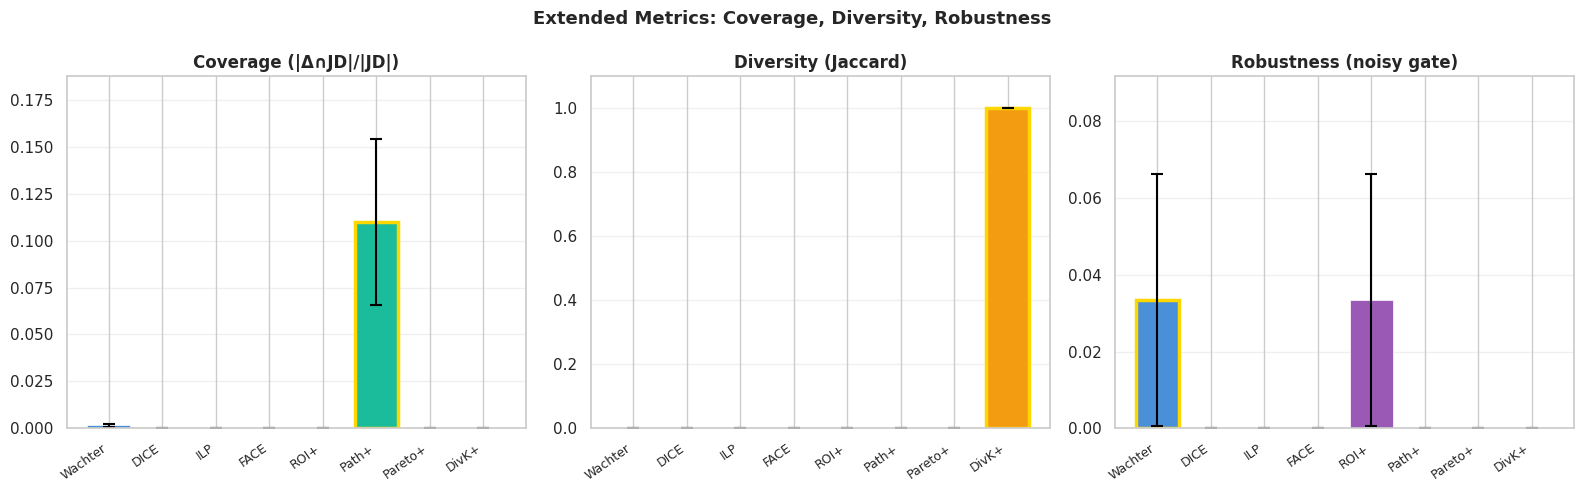

In [42]:
# ── Figure: Coverage, Diversity, Robustness grouped bar ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Extended Metrics: Coverage, Diversity, Robustness',
             fontsize=13, fontweight='bold')

for ax, key, title in [
    (axes[0], 'coverage',   'Coverage (|Δ∩JD|/|JD|)'),
    (axes[1], 'diversity',  'Diversity (Jaccard)'),
    (axes[2], 'robustness', 'Robustness (noisy gate)'),
]:
    vals   = [np.mean(ext_metrics[m][key]) for m in mnames]
    sems   = [np.std(ext_metrics[m][key]) / max(np.sqrt(len(ext_metrics[m][key])), 1)
              for m in mnames]
    colors = [METHOD_COLORS.get(m, '#888') for m in mnames]
    bars   = ax.bar(range(len(mnames)), vals, color=colors,
                    edgecolor='white', linewidth=0.5)
    ax.errorbar(range(len(mnames)), vals, yerr=sems,
                fmt='none', color='black', capsize=4, capthick=1.5)
    best_i = int(np.argmax(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(2.5)
    ax.set_xticks(range(len(mnames)))
    ax.set_xticklabels(
        [m.replace('Graph-Pathway+','Path+').replace('Greedy-ROI+','ROI+')
          .replace('Diverse-K+','DivK+') for m in mnames],
        rotation=35, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, min(max(vals) * 1.25 + 0.05, 1.1))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig('fig_extended_metrics.png')
plt.show()


---
## Fairness / Bias Analysis

**Research question:** Does the MoEv2 scorer or the recourse system treat candidates differently based on inferred demographic signals?

**Method — minimal name perturbation:**  
Insert `"Name: <name>."` at the top of each resume and measure:
1. **Score delta** — shift in base score vs the no-name baseline (scoring bias)
2. **Recourse burden** — skills needed to cross threshold (recourse disparity)
3. **Validity rate** — whether recourse succeeds at all

Names are drawn from five demographic cells with known demographic signals in NLP embeddings:

| Group | Names tested |
|-------|-------------|
| White Male | James Smith, Robert Johnson, Michael Davis |
| White Female | Emily Wilson, Sarah Miller, Jennifer Moore |
| Black Male | Jamal Williams, DeShawn Brown, Marcus Jackson |
| Black Female | Aisha Harris, Latoya Thomas, Keisha Robinson |
| Asian | Wei Zhang, Priya Patel, Hiroshi Tanaka |

Each name is tested on the same 30 failing candidates; results are averaged.  
Statistical significance assessed via Mann-Whitney U (White Male as reference group).


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# Fairness Analysis — Name Perturbation Test
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu

DEMO_NAMES = {
    'White Male':   ['James Smith',    'Robert Johnson', 'Michael Davis'],
    'White Female': ['Emily Wilson',   'Sarah Miller',   'Jennifer Moore'],
    'Black Male':   ['Jamal Williams', 'DeShawn Brown',  'Marcus Jackson'],
    'Black Female': ['Aisha Harris',   'Latoya Thomas',  'Keisha Robinson'],
    'Asian':        ['Wei Zhang',      'Priya Patel',    'Hiroshi Tanaka'],
}
GROUP_COLORS = {
    'White Male':   '#4a90d9',
    'White Female': '#e91e8c',
    'Black Male':   '#2ecc71',
    'Black Female': '#e67e22',
    'Asian':        '#9b59b6',
}

def insert_name(text: str, name: str) -> str:
    return f"Name: {name}. {text}"

N_FAIR = 30
fair_sample = eval_df.sample(min(N_FAIR, len(eval_df)), random_state=11)

fair_records = []
for _, row in tqdm(fair_sample.iterrows(), total=len(fair_sample), desc='Fairness'):
    enc_base  = encode_sep(row[res_col], row[jd_col_use])
    r_ids_f   = row['res_skill_ids']
    j_ids_f   = row['jd_skill_ids']
    base_sc, *_ = score_moe(enc_base, r_ids_f, j_ids_f)

    for group, names in DEMO_NAMES.items():
        g_score_deltas, g_l0, g_valid, g_effort = [], [], [], []
        for name in names:
            mod_text = insert_name(str(row[res_col]), name)
            enc_mod  = encode_sep(mod_text, row[jd_col_use])
            _set_cache(enc_mod, j_ids_f)
            named_sc, *_ = score_moe(enc_mod, r_ids_f, j_ids_f)

            # Quick greedy recourse with named resume
            cands = [s for s in get_candidates(row['extracted_skills_res'],
                                                row['extracted_skills_jd'], hops=1)
                     if s in skill_to_id and skill_to_id[s] not in set(r_ids_f)][:30]
            deltas_f = skill_deltas(enc_mod, r_ids_f, j_ids_f, cands, named_sc)
            sorted_d = sorted(deltas_f.items(), key=lambda x: -x[1])

            cur_sc  = named_sc; steps = 0
            cur_aug = list(r_ids_f); added_sk = []
            for s, _ in sorted_d[:12]:
                if cur_sc >= THRESHOLD_ABS: break
                cur_aug = list(set(cur_aug) | {skill_to_id[s]})
                added_sk.append(s)
                cur_sc = score_with_extra_ids(enc_mod, list(r_ids_f), j_ids_f,
                                              [skill_to_id[sk] for sk in added_sk
                                               if sk in skill_to_id])
                steps += 1

            g_score_deltas.append(named_sc - base_sc)
            g_l0.append(steps)
            g_valid.append(int(cur_sc >= THRESHOLD_ABS))
            g_effort.append(float(np.mean([skill_difficulty.get(s,.5) for s in added_sk]))
                            if added_sk else 0.)

        fair_records.append({
            'group':       group,
            'score_delta': float(np.mean(g_score_deltas)),
            'mean_l0':     float(np.mean(g_l0)),
            'validity':    float(np.mean(g_valid)),
            'mean_effort': float(np.mean(g_effort)),
        })

df_fair = pd.DataFrame(fair_records)
print('Fairness analysis complete.')
print(df_fair.groupby('group')[['score_delta','mean_l0','validity','mean_effort']]
      .mean().round(3))


Fairness:   0%|          | 0/30 [00:00<?, ?it/s]

Fairness analysis complete.
              score_delta  mean_l0  validity  mean_effort
group                                                    
Asian               0.002   11.900     0.011        0.988
Black Female        0.002   11.756     0.022        0.977
Black Male          0.003   11.967     0.011        0.988
White Female        0.003   11.933     0.022        0.988
White Male          0.003   11.978     0.011        0.988


In [44]:
# ── Mann-Whitney U significance tests (White Male as reference group) ─────────
print('\nMann-Whitney U test (White Male vs. each group, score_delta):')
wm_scores = df_fair[df_fair.group == 'White Male']['score_delta'].values
ref_l0    = df_fair[df_fair.group == 'White Male']['mean_l0'].values

for g in ['White Female', 'Black Male', 'Black Female', 'Asian']:
    g_scores = df_fair[df_fair.group == g]['score_delta'].values
    g_l0     = df_fair[df_fair.group == g]['mean_l0'].values
    stat_s, p_s = mannwhitneyu(wm_scores, g_scores, alternative='two-sided')
    stat_l, p_l = mannwhitneyu(ref_l0,    g_l0,     alternative='two-sided')
    sig_s = '**' if p_s < .05 else ('*' if p_s < .1 else 'ns')
    sig_l = '**' if p_l < .05 else ('*' if p_l < .1 else 'ns')
    print(f'  {g:16s}  score_delta: U={stat_s:.0f} p={p_s:.3f} {sig_s}  '
          f'| L0: U={stat_l:.0f} p={p_l:.3f} {sig_l}')

print('\n* p<0.1  ** p<0.05  ns not significant')



Mann-Whitney U test (White Male vs. each group, score_delta):
  White Female      score_delta: U=477 p=0.695 ns  | L0: U=466 p=0.544 ns
  Black Male        score_delta: U=476 p=0.706 ns  | L0: U=450 p=1.000 ns
  Black Female      score_delta: U=478 p=0.684 ns  | L0: U=450 p=1.000 ns
  Asian             score_delta: U=463 p=0.853 ns  | L0: U=450 p=1.000 ns

* p<0.1  ** p<0.05  ns not significant


Saved fig_fairness_bars.png


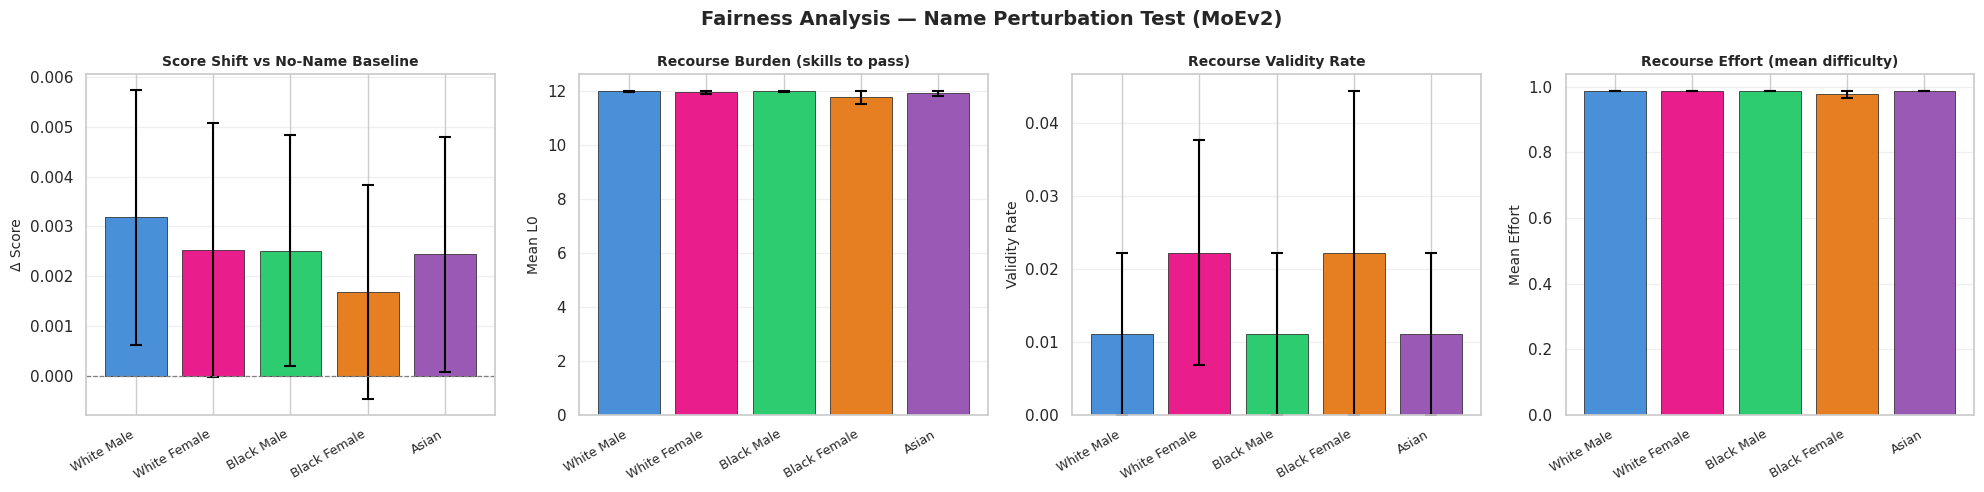

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — Fairness: Score Bias, Recourse Burden, Validity by Demographic Group
# ══════════════════════════════════════════════════════════════════════════════
group_order = ['White Male', 'White Female', 'Black Male', 'Black Female', 'Asian']
palette     = [GROUP_COLORS[g] for g in group_order]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Fairness Analysis — Name Perturbation Test (MoEv2)',
             fontsize=14, fontweight='bold')

for ax, col, title, ylabel in [
    (axes[0], 'score_delta',  'Score Shift vs No-Name Baseline',   'Δ Score'),
    (axes[1], 'mean_l0',      'Recourse Burden (skills to pass)',   'Mean L0'),
    (axes[2], 'validity',     'Recourse Validity Rate',             'Validity Rate'),
    (axes[3], 'mean_effort',  'Recourse Effort (mean difficulty)',  'Mean Effort'),
]:
    means = [df_fair[df_fair.group == g][col].mean() for g in group_order]
    sems  = [df_fair[df_fair.group == g][col].sem()  for g in group_order]
    bars  = ax.bar(range(len(group_order)), means, color=palette,
                   edgecolor='k', linewidth=0.5)
    ax.errorbar(range(len(group_order)), means, yerr=sems,
                fmt='none', color='black', capsize=4, capthick=1.5)
    if col == 'score_delta':
        ax.axhline(0, color='grey', lw=0.9, ls='--')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig('fig_fairness_bars.png')
plt.show()


Saved fig_fairness_heatmap.png


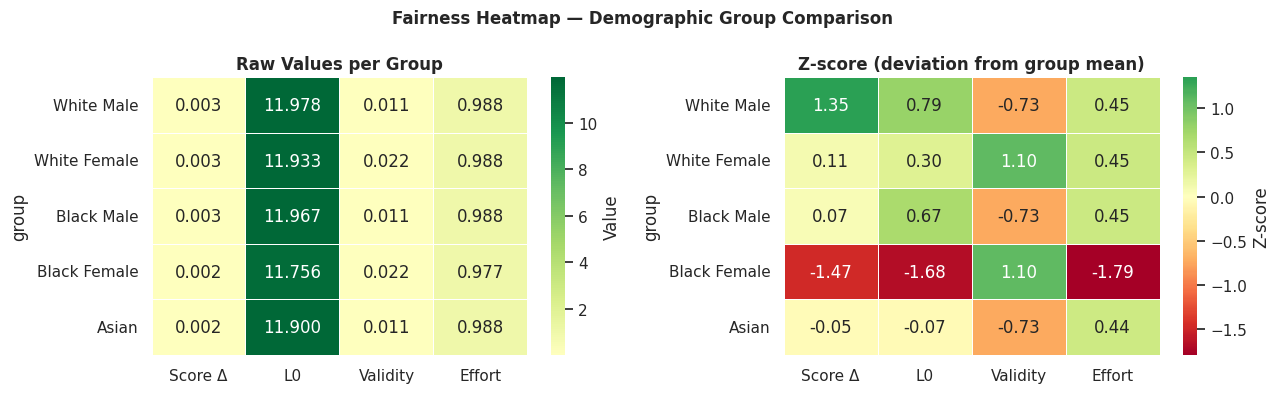

In [46]:
# ── Fairness Heatmap — all metrics across groups ─────────────────────────────
fair_summary = (df_fair.groupby('group')[['score_delta','mean_l0','validity','mean_effort']]
                .mean().loc[group_order])
fair_summary.columns = ['Score Δ', 'L0', 'Validity', 'Effort']

# Normalise for heatmap (row-wise Z-score)
fair_norm = (fair_summary - fair_summary.mean()) / (fair_summary.std() + 1e-8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(fair_summary.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax1, cbar_kws={'label': 'Value'})
ax1.set_title('Raw Values per Group', fontweight='bold')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

sns.heatmap(fair_norm.round(2), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax2, cbar_kws={'label': 'Z-score'})
ax2.set_title('Z-score (deviation from group mean)', fontweight='bold')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

fig.suptitle('Fairness Heatmap — Demographic Group Comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('fig_fairness_heatmap.png')
plt.show()


/tmp/ipykernel_55/1355166284.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=group_order, patch_artist=True,


Saved fig_bias_boxplot.png


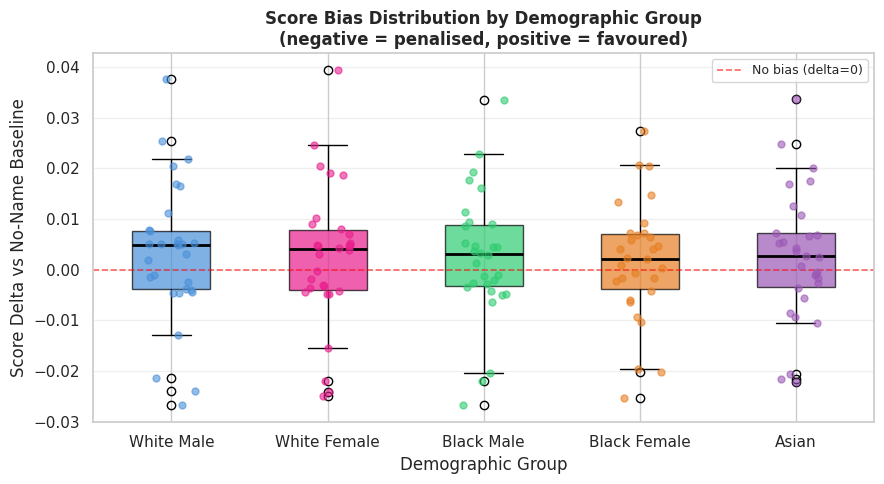

In [47]:
# ── Score Delta Distribution per Group (box + swarm) ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

data_by_group = [df_fair[df_fair.group == g]['score_delta'].values for g in group_order]
bp = ax.boxplot(data_by_group, labels=group_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)

# Overlay individual points (jittered)
for i, (g, color) in enumerate(zip(group_order, palette)):
    vals = df_fair[df_fair.group == g]['score_delta'].values
    jitter = np.random.default_rng(i).uniform(-0.15, 0.15, len(vals))
    ax.scatter(i + 1 + jitter, vals, color=color, s=25, alpha=0.6, zorder=3)

ax.axhline(0, color='red', ls='--', lw=1.2, alpha=0.6, label='No bias (delta=0)')
ax.set_xlabel('Demographic Group', fontsize=12)
ax.set_ylabel('Score Delta vs No-Name Baseline', fontsize=12)
ax.set_title('Score Bias Distribution by Demographic Group\n'
             '(negative = penalised, positive = favoured)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
savefig('fig_bias_boxplot.png')
plt.show()


---
## Sensitivity Analysis

How sensitive is recourse success to the choice of threshold tau?


Sens. eval:   0%|          | 0/30 [00:00<?, ?it/s]

Saved fig_threshold_sensitivity.png


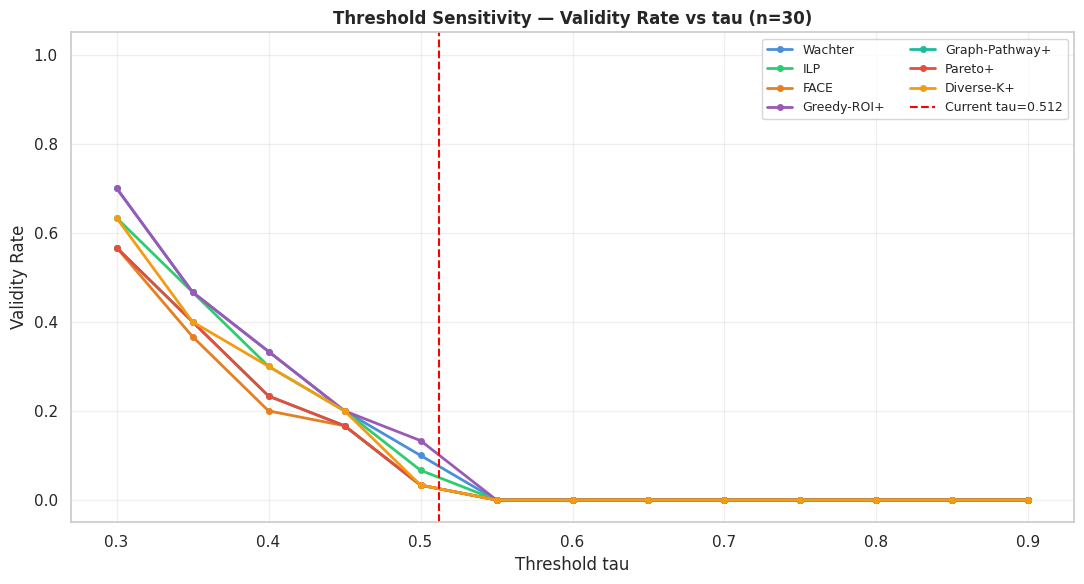

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# Threshold Sensitivity — Validity Rate vs tau for all methods
# ══════════════════════════════════════════════════════════════════════════════
tau_range = np.linspace(0.3, 0.9, 13)
sens_sample = eval_df.sample(min(30, len(eval_df)), random_state=17)

# Pre-compute results once (at default threshold)
sens_results = []
for _, row in tqdm(sens_sample.iterrows(), total=len(sens_sample), desc='Sens. eval'):
    enc_s = encode_sep(row[res_col], row[jd_col_use])
    _set_cache(enc_s, row['jd_skill_ids'])
    row_res = {}
    for mname, mobj in [('Wachter',        wachter),
                         ('ILP',            ilp),
                         ('FACE',           face),
                         ('Greedy-ROI+',    greedy_roi),
                         ('Graph-Pathway+', graph_path),
                         ('Pareto+',        pareto_plus),
                         ('Diverse-K+',     diverse_k)]:
        try:
            r = mobj.run(enc_s, row['res_skill_ids'], row['jd_skill_ids'],
                         row['extracted_skills_res'], row['extracted_skills_jd'])
            row_res[mname] = r.score_after
        except Exception:
            row_res[mname] = 0.
    sens_results.append(row_res)

# Compute validity at each tau
fig, ax = plt.subplots(figsize=(11, 6))
sens_methods = ['Wachter','ILP','FACE','Greedy-ROI+','Graph-Pathway+','Pareto+','Diverse-K+']
for mname in sens_methods:
    validity_at_tau = []
    for tau in tau_range:
        v = np.mean([int(r.get(mname, 0.) >= tau) for r in sens_results])
        validity_at_tau.append(v)
    ax.plot(tau_range, validity_at_tau, marker='o', markersize=4,
            color=METHOD_COLORS.get(mname, '#888'), lw=2, label=mname)

ax.axvline(THRESHOLD_ABS, color='red', ls='--', lw=1.5,
           label=f'Current tau={THRESHOLD_ABS:.3f}')
ax.set_xlabel('Threshold tau', fontsize=12)
ax.set_ylabel('Validity Rate', fontsize=12)
ax.set_title('Threshold Sensitivity — Validity Rate vs tau (n=30)', fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('fig_threshold_sensitivity.png')
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Failure Mode Analysis — Why does recourse fail?
# ══════════════════════════════════════════════════════════════════════════════
fail_analysis = {'no_candidates': 0, 'score_plateau': 0, 'budget_exceeded': 0,
                 'succeeded': 0, 'partial': 0}

wachter_details = []
for _, row in eval_df.iterrows():
    enc_f = encode_sep(row[res_col], row[jd_col_use])
    _set_cache(enc_f, row['jd_skill_ids'])
    base_f, *_ = score_moe(enc_f, row['res_skill_ids'], row['jd_skill_ids'])

    cands = [s for s in get_candidates(row['extracted_skills_res'],
                                        row['extracted_skills_jd'], hops=2)
             if s in skill_to_id and skill_to_id[s] not in set(row['res_skill_ids'])]

    if not cands:
        fail_analysis['no_candidates'] += 1
        wachter_details.append({'gap': base_f - THRESHOLD_ABS, 'reason': 'no_candidates'})
        continue

    deltas_f = skill_deltas(enc_f, row['res_skill_ids'], row['jd_skill_ids'],
                             cands[:30], base_f)
    max_delta = max(deltas_f.values()) if deltas_f else 0.

    r_w = wachter.run(enc_f, row['res_skill_ids'], row['jd_skill_ids'],
                      row['extracted_skills_res'], row['extracted_skills_jd'])
    if r_w.valid:
        fail_analysis['succeeded'] += 1
        wachter_details.append({'gap': base_f - THRESHOLD_ABS, 'reason': 'success'})
    elif max_delta < 0.001:
        fail_analysis['score_plateau'] += 1
        wachter_details.append({'gap': base_f - THRESHOLD_ABS, 'reason': 'plateau'})
    elif r_w.proximity_l0 >= 5:
        fail_analysis['budget_exceeded'] += 1
        wachter_details.append({'gap': base_f - THRESHOLD_ABS, 'reason': 'budget'})
    else:
        fail_analysis['partial'] += 1
        wachter_details.append({'gap': base_f - THRESHOLD_ABS, 'reason': 'partial'})

df_fail = pd.DataFrame(wachter_details)
print('Wachter Failure Mode Analysis:')
for k, v in fail_analysis.items():
    pct = 100 * v / max(sum(fail_analysis.values()), 1)
    print(f'  {k:20s}: {v:3d} ({pct:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart of failure modes
labels = list(fail_analysis.keys())
sizes  = list(fail_analysis.values())
colors_pie = ['#2ecc71','#e74c3c','#f39c12','#9b59b6','#4a90d9']
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_pie[:len(labels)], startangle=140,
    textprops={'fontsize': 9})
ax1.set_title('Wachter Failure Modes', fontweight='bold')

# Gap distribution by outcome
for reason, color in [('success','#2ecc71'), ('partial','#f39c12'),
                       ('budget','#e74c3c'), ('plateau','#9b59b6')]:
    sub = df_fail[df_fail.reason == reason]['gap']
    if len(sub): ax2.hist(sub, bins=12, alpha=0.6, color=color, label=reason)
ax2.axvline(0, color='black', ls='--', lw=1, label='At threshold')
ax2.set_xlabel('Base Score - Threshold (gap)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Score Gap by Recourse Outcome', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
savefig('fig_failure_modes.png')
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Skill Co-Recommendation Network — Which skills are recommended together?
# Edges weighted by co-recommendation frequency across Wachter results.
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

# Collect Wachter recommendations for all eval candidates
co_recs = Counter()
all_recs_per_cand = []

for _, row in eval_df.iterrows():
    enc_cr = encode_sep(row[res_col], row[jd_col_use])
    _set_cache(enc_cr, row['jd_skill_ids'])
    r_cr = wachter.run(enc_cr, row['res_skill_ids'], row['jd_skill_ids'],
                       row['extracted_skills_res'], row['extracted_skills_jd'])
    all_recs_per_cand.append(r_cr.skills_added)
    for s1, s2 in combinations(set(r_cr.skills_added), 2):
        pair = tuple(sorted([s1, s2]))
        co_recs[pair] += 1

# Build graph
G_co = nx.Graph()
for (s1, s2), w in co_recs.most_common(40):
    G_co.add_edge(s1, s2, weight=w)

if G_co.nodes():
    # Node size = degree centrality; colour by PageRank
    deg_c   = nx.degree_centrality(G_co)
    pr_vals = nx.pagerank(G_co, weight='weight')
    nodes   = list(G_co.nodes())
    sizes   = [1200 * deg_c.get(n, 0.1) + 200 for n in nodes]
    pr_norm = [pr_vals.get(n, 0.)              for n in nodes]

    fig, ax = plt.subplots(figsize=(13, 9))
    pos = nx.spring_layout(G_co, seed=42, k=2.0)
    edge_widths = [G_co[u][v]['weight'] * 0.4 for u, v in G_co.edges()]
    nx.draw_networkx_edges(G_co, pos, width=edge_widths,
                           alpha=0.4, edge_color='#888', ax=ax)
    sc = nx.draw_networkx_nodes(G_co, pos, node_size=sizes,
                                node_color=pr_norm, cmap='plasma',
                                alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G_co, pos, font_size=7, ax=ax)
    plt.colorbar(sc, ax=ax, label='PageRank (recommendation centrality)')
    ax.set_title('Skill Co-Recommendation Network (Wachter, top-40 pairs)\n'
                 'Node size = degree centrality; colour = PageRank',
                 fontweight='bold', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    savefig('fig_co_recommendation_network.png')
    plt.show()
    print(f'Nodes: {G_co.number_of_nodes()}  Edges: {G_co.number_of_edges()}')
    top5 = [p for p, _ in co_recs.most_common(5)]
    print(f'Top co-recommended pairs: {top5}')
else:
    print('Not enough co-recommendations to build network.')
